# Pareto Frontier Analysis for Diversified QUBO Portfolio Optimization

This notebook explores the Pareto frontier by varying the risk aversion parameter in diversified (restricted) QUBO-based portfolio optimization on the wide dataset (680 assets).

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import time
import logging
import os
import warnings
from datetime import datetime, timedelta
from functools import partial
from pathlib import Path
from optimization_engines import (
    equal_weights_baseline,
    genetic_algorithm_qubo,
    scipy_slsqp_qubo,
    riskfolio_qubo,
    dwave_cqm_qubo,
    portfolio_stats
)
from analysis_utils import (
    write_pickle_dict,
    read_pickle_dict,
    plot_pareto_frontier,
    compare_pareto_frontiers,
    plot_weight_evolution,
    extract_pareto_frontier
)

SEED = 12
np.random.seed(SEED)
msg_level = logging.INFO
warnings.filterwarnings("ignore", category=RuntimeWarning)

In [2]:
# Create a logger
logger = logging.getLogger("pareto_logger")
logger.setLevel(msg_level)

## Data Paths

In [3]:
benchmark_path = '../../data/benchmark_gspc.pkl'
source_path = '../../data/stocks_adjclose.pkl'
source_path_extended = '../../data/etfs_close.pkl'
results_base_path = '../../results/pareto_optimization/'

# Create results directory if it doesn't exist
os.makedirs(results_base_path, exist_ok=True)
print(f"Results will be saved to: {results_base_path}")

Results will be saved to: ../../results/pareto_optimization/


## Data Loading

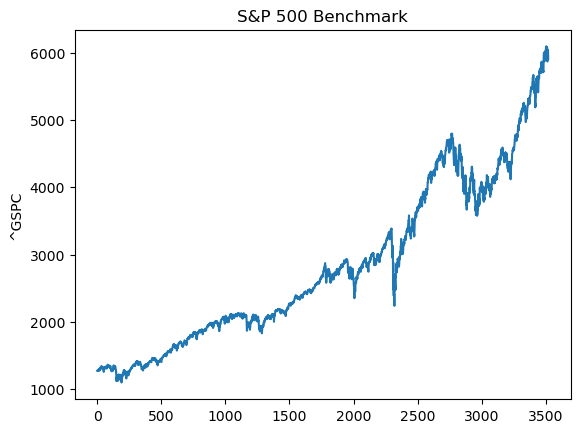

Ticker,ds,^GSPC
0,2011-01-03,1271.869995
1,2011-01-04,1270.199951
2,2011-01-05,1276.560059
3,2011-01-06,1273.849976
4,2011-01-07,1271.500000


In [4]:
benchmark = pd.read_pickle(benchmark_path)
sns.lineplot(benchmark['^GSPC'])
plt.title('S&P 500 Benchmark')
plt.show()
benchmark.head()

In [5]:
source_extended = pd.read_pickle(source_path_extended)
print(f"Extended data shape: {source_extended.shape}")
source_extended.head()

Extended data shape: (3521, 242)


Ticker,ds,AADR,ACWI,ACWX,AFG,AGG,AMLP,BIL,BIV,BND,...,XLP,XLU,XLV,XLY,XME,XOP,XPH,XRT,XSD,XTNT
0,2011-01-03,26.494179,35.018154,30.182961,14.173727,71.489235,26.573900,76.281036,50.488926,53.083935,...,19.910189,19.169912,24.896574,31.685013,57.138588,168.841461,17.785585,19.920353,25.601683,1074.0
1,2011-01-04,26.450108,34.981026,30.019852,14.104879,71.509521,26.491484,76.281036,50.562424,53.090553,...,19.855919,19.261232,24.974888,31.509201,56.714920,167.352570,17.651617,19.548199,25.860556,1032.0
2,2011-01-05,26.291458,34.981026,29.992662,14.066156,71.164383,26.458506,76.281036,50.188774,52.858776,...,19.862703,19.139469,25.029711,31.768719,57.097866,167.922791,17.774096,19.531855,26.151806,1050.0
3,2011-01-06,26.291458,34.758274,29.727602,14.264087,71.177925,26.458506,76.281036,50.378658,52.905167,...,19.794865,19.157736,25.131519,31.576189,56.389015,167.099167,17.873608,19.253756,26.558626,1026.0
4,2011-01-07,26.150438,34.632030,29.578085,14.195246,71.408035,26.491484,76.264374,50.678814,53.103794,...,19.693110,19.224695,25.115862,31.559439,56.112007,167.701004,17.892746,19.196499,26.697304,1050.0


In [6]:
source = pd.read_pickle(source_path)
print(f"Source data shape: {source.shape}")
has_any_nan = source.isnull().values.any()
print(f"Any NaN in source: {has_any_nan}")

Source data shape: (3522, 439)
Any NaN in source: False


In [7]:
source_wide = pd.merge(source, source_extended, on='ds', how='left').set_index('ds').dropna()
print(f"Wide dataset shape: {source_wide.shape}")
has_any_nan = source_wide.isnull().values.any()
print(f"Any NaN in source_wide: {has_any_nan}")
source_wide.head()

Wide dataset shape: (3521, 680)
Any NaN in source_wide: False


Ticker,A,AAPL,ABT,ACGL,ACN,ADBE,ADI,ADM,ADP,ADSK,...,XLP,XLU,XLV,XLY,XME,XOP,XPH,XRT,XSD,XTNT
ds,,,,,,,,,,,,,,,,,,,,,
2011-01-03,26.781836,9.917951,16.942663,9.349445,37.585785,31.290001,27.436106,20.712511,29.848969,39.270000,...,19.910189,19.169912,24.896574,31.685013,57.138588,168.841461,17.785585,19.920353,25.601683,1074.0
2011-01-04,26.532440,9.969709,17.102097,9.291334,37.338249,31.510000,27.125227,20.698887,29.741137,38.529999,...,19.855919,19.261232,24.974888,31.509201,56.714920,167.352570,17.651617,19.548199,25.860556,1032.0
2011-01-05,26.474880,10.051261,17.102097,9.305071,37.346004,32.220001,27.183071,20.794275,30.216925,41.240002,...,19.862703,19.139469,25.029711,31.768719,57.097866,167.922791,17.774096,19.531855,26.151806,1050.0
2011-01-06,26.526041,10.043136,17.066668,9.179339,37.485237,32.270000,27.334898,21.591436,30.451658,41.259998,...,19.794865,19.157736,25.131519,31.576189,56.389015,167.099167,17.873608,19.253756,26.558626,1026.0
2011-01-07,26.615564,10.115060,17.137522,9.109608,37.547104,32.040001,27.175838,21.768579,30.521458,40.759998,...,19.693110,19.224695,25.115862,31.559439,56.112007,167.701004,17.892746,19.196499,26.697304,1050.0


## Parameters

In [ ]:
parameters = {
    "n_periods": 10,  # Run 10 different time ranges
    "population_size": 100,
    "num_generations": 100,
    "mutation_rate": 0.1,
    "elitism": 0.1,
    "budget": 1_000_000,
    "days_to_avg": 30,  # 30-day averaging period
    "days_to_opt": 30,   # 30-day optimization/testing period
    # Risk levels for Pareto frontier exploration - lambda from 0 to 1 with steps of 0.1
    "risk_levels": [i/10 for i in range(11)]  # [0.0, 0.1, 0.2, ..., 1.0]
}

print(f"Optimization Parameters:")
for key, value in parameters.items():
    print(f"  {key}: {value}")

Optimization Parameters:
  n_periods: 10
  population_size: 100
  num_generations: 100
  mutation_rate: 0.1
  elitism: 0.1
  budget: 1000000
  days_to_avg: 30
  days_to_opt: 30
  risk_levels: [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]


## Pareto Optimization Functions

In [9]:
def pareto_sweep(data, optimization_function, risk_levels, **opt_kwargs):
    """
    Perform Pareto frontier sweep by optimizing across multiple risk levels.
    
    Args:
        data: Stock price DataFrame
        optimization_function: Optimization function to use
        risk_levels: List of risk aversion parameters to explore
        **opt_kwargs: Additional arguments for optimization function
        
    Returns:
        results_dict: Dictionary mapping risk_level -> optimization results
    """
    results = {}
    
    for risk_level in risk_levels:
        print(f"\nOptimizing with risk_level = {risk_level:.3f}")
        start_time = time.time()
        
        try:
            # Optimize for this risk level
            weights = optimization_function(data, risk_level=risk_level, **opt_kwargs)
            
            # Calculate portfolio statistics
            port_return, port_vol = portfolio_stats(weights, data)
            
            # Store results
            results[risk_level] = {
                'weights': weights,
                'portfolio_return': port_return,
                'portfolio_risk': port_vol,
                'portfolio_variance': port_vol ** 2,
                'sharpe_ratio': port_return / port_vol if port_vol > 0 else 0,
                'execution_time': time.time() - start_time,
                'risk_level': risk_level
            }
            
            print(f"  Return: {port_return:.6f}, Risk: {port_vol:.6f}, "
                  f"Sharpe: {results[risk_level]['sharpe_ratio']:.4f}, "
                  f"Time: {results[risk_level]['execution_time']:.2f}s")
            
        except Exception as e:
            print(f"  ERROR: {str(e)}")
            results[risk_level] = None
    
    return results


def run_pareto_optimization_period(period, solver_name, solver_key, optimization_function, 
                                   data, benchmark, results_dict, parameters, 
                                   results_base_path, **opt_kwargs):
    """
    Run Pareto optimization for a single period and single solver.
    
    Args:
        period: Period index (0-9)
        solver_name: Display name of the solver (e.g., 'Genetic Algorithm', 'SciPy SLSQP')
        solver_key: Short key for file naming (e.g., 'ga', 'slsqp', 'riskfolio')
        optimization_function: The optimization function to use
        data: Full stock price DataFrame
        benchmark: Benchmark DataFrame
        results_dict: Dictionary to store results (will be modified in place)
        parameters: Dictionary of optimization parameters
        results_base_path: Base path for saving results
        **opt_kwargs: Additional arguments for optimization function
    """
    print(f"\n{'='*80}")
    print(f"PERIOD {period} - {solver_name} (Wide Dataset)")
    print(f"{'='*80}")
    
    results_path = results_base_path + f'pareto_wide_{solver_key}_period_{period}.pkl'
    
    if not os.path.exists(results_path):
        # Get period data
        df_avg, df_opt, df_b_avg, df_b_opt = get_period_data(
            data, benchmark, period,
            days_to_avg=parameters['days_to_avg'],
            days_to_opt=parameters['days_to_opt']
        )
        print(f"Averaging period: {df_avg.index[0]} to {df_avg.index[-1]}")
        print(f"Optimization period: {df_opt.index[0]} to {df_opt.index[-1]}")
        
        # Run Pareto sweep on averaging data with diversified QUBO
        results = pareto_sweep(
            df_avg,
            optimization_function,
            parameters['risk_levels'],
            **opt_kwargs
        )
        write_pickle_dict(results, results_path)
    else:
        print(f"Loading existing results for period {period}...")
        results = read_pickle_dict(results_path)
    
    results_dict[period] = results
    
    # Plot efficient frontier for this period
    plot_pareto_frontier(results, title=f"Efficient Frontier - {solver_name} Period {period} (Wide Dataset)")

In [10]:
def get_period_data(data, benchmark, period, days_to_avg=30, days_to_opt=30, seed=SEED):
    """
    Get data for a specific period using the same approach as other optimization notebooks.
    
    Args:
        data: Full stock price DataFrame
        benchmark: Benchmark DataFrame  
        period: Period index (0-9 for 10 periods)
        days_to_avg: Number of days to use for averaging (30)
        days_to_opt: Number of days to use for optimization/testing (30)
        seed: Random seed
        
    Returns:
        df_avg: Data for 30-day averaging period
        df_opt: Data for 30-day optimization period
        df_b_avg: Benchmark for averaging period
        df_b_opt: Benchmark for optimization period
    """
    df2 = data.reset_index()
    benchmark2 = benchmark.reset_index()
    
    # Sample 100 different starting dates deterministically
    np.random.seed(seed)
    max_samples = 100
    valid_range = range(days_to_avg, len(df2) - days_to_avg - days_to_opt)
    sample_indices = np.random.choice(valid_range, size=min(max_samples, len(valid_range)), replace=False)
    
    # Get the specific period
    if period >= len(sample_indices):
        raise ValueError(f"Period {period} exceeds available samples ({len(sample_indices)})")
    
    idx = sample_indices[period]
    
    # Averaging period (30 days before idx)
    df_avg = df2.iloc[idx - days_to_avg:idx, :].set_index('ds')
    df_b_avg = benchmark2.iloc[idx - days_to_avg:idx, :].set_index('ds').drop(['index'], axis=1, errors='ignore')
    
    # Optimization period (30 days after idx)
    df_opt = df2.iloc[idx:idx + days_to_opt, :].set_index('ds')
    df_b_opt = benchmark2.iloc[idx:idx + days_to_opt, :].set_index('ds').drop(['index'], axis=1, errors='ignore')
    
    return df_avg, df_opt, df_b_avg, df_b_opt

## Wide Dataset Pareto Frontier (680 Assets) - All Periods

In [11]:
# Initialize storage for all periods
all_periods_results_wide = {
    'genetic_algorithm': {},
    'scipy_slsqp': {},
    'riskfolio': {}
}

print(f"\nRunning Pareto optimization for Wide Dataset across {parameters['n_periods']} time periods...")
print("=" * 80)


Running Pareto optimization for Wide Dataset across 10 time periods...


### Genetic Algorithm - Wide Dataset (All Periods)


PERIOD 0 - Genetic Algorithm (Wide Dataset)
Loading existing results for period 0...


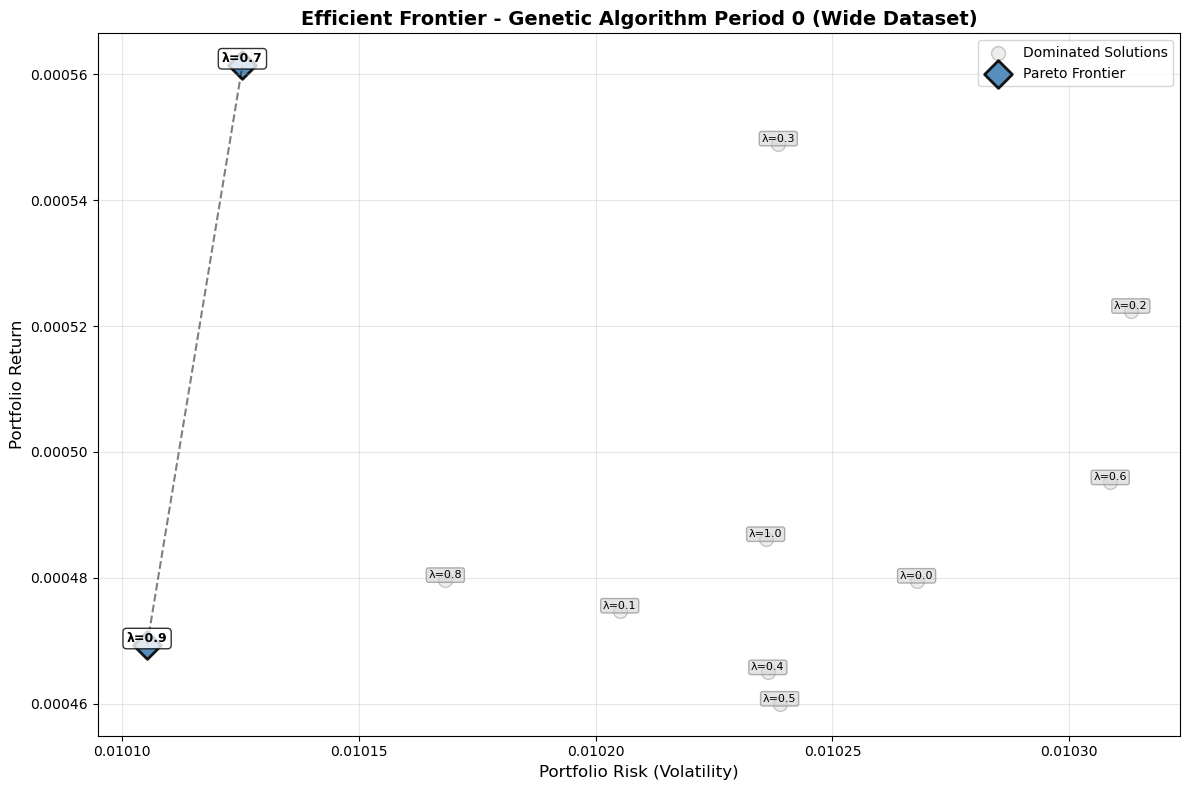


Pareto Frontier Summary:
Total solutions evaluated: 11
Pareto-optimal solutions: 2
Efficiency: 18.2%

Pareto Solutions:
Risk Level   Return       Risk         Sharpe      
------------------------------------------------------------
0.900        0.000469     0.010105     0.0464      
0.700        0.000561     0.010125     0.0555      

PERIOD 1 - Genetic Algorithm (Wide Dataset)
Loading existing results for period 1...


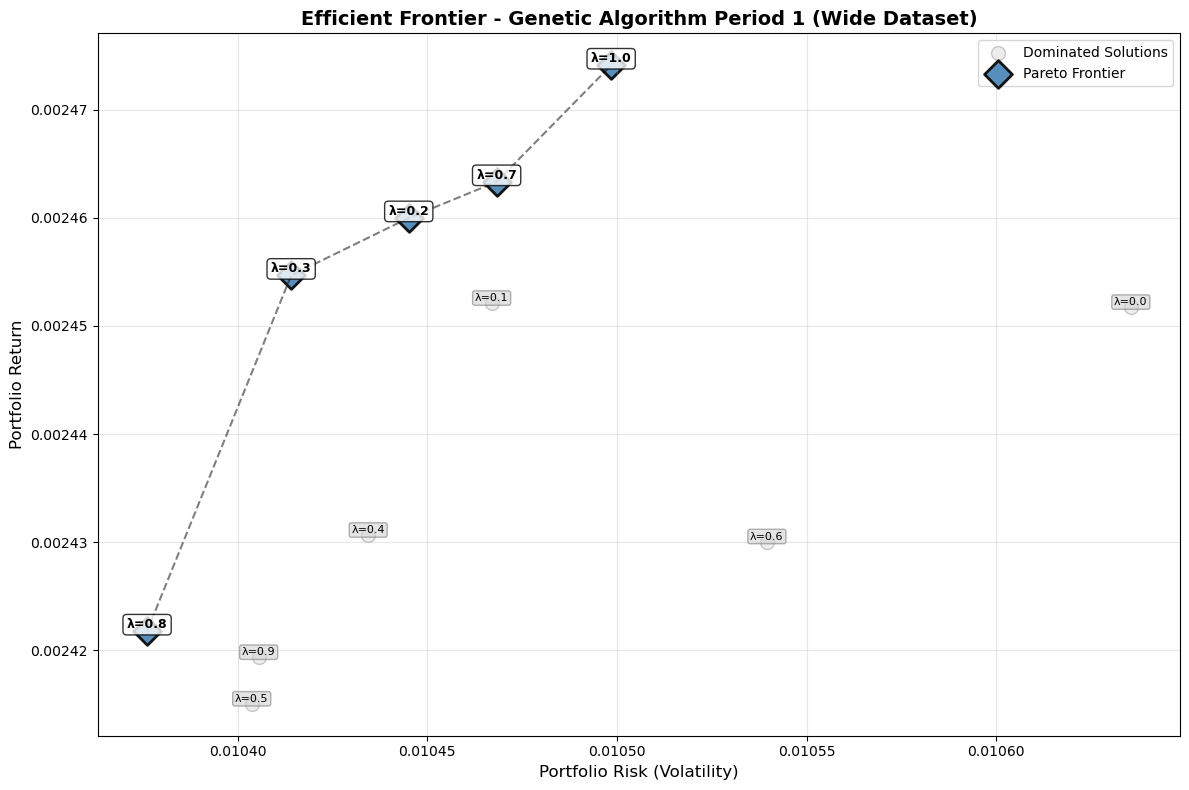


Pareto Frontier Summary:
Total solutions evaluated: 11
Pareto-optimal solutions: 5
Efficiency: 45.5%

Pareto Solutions:
Risk Level   Return       Risk         Sharpe      
------------------------------------------------------------
0.800        0.002422     0.010376     0.2334      
0.300        0.002455     0.010414     0.2357      
0.200        0.002460     0.010445     0.2355      
0.700        0.002463     0.010468     0.2353      
1.000        0.002474     0.010498     0.2357      

PERIOD 2 - Genetic Algorithm (Wide Dataset)
Loading existing results for period 2...


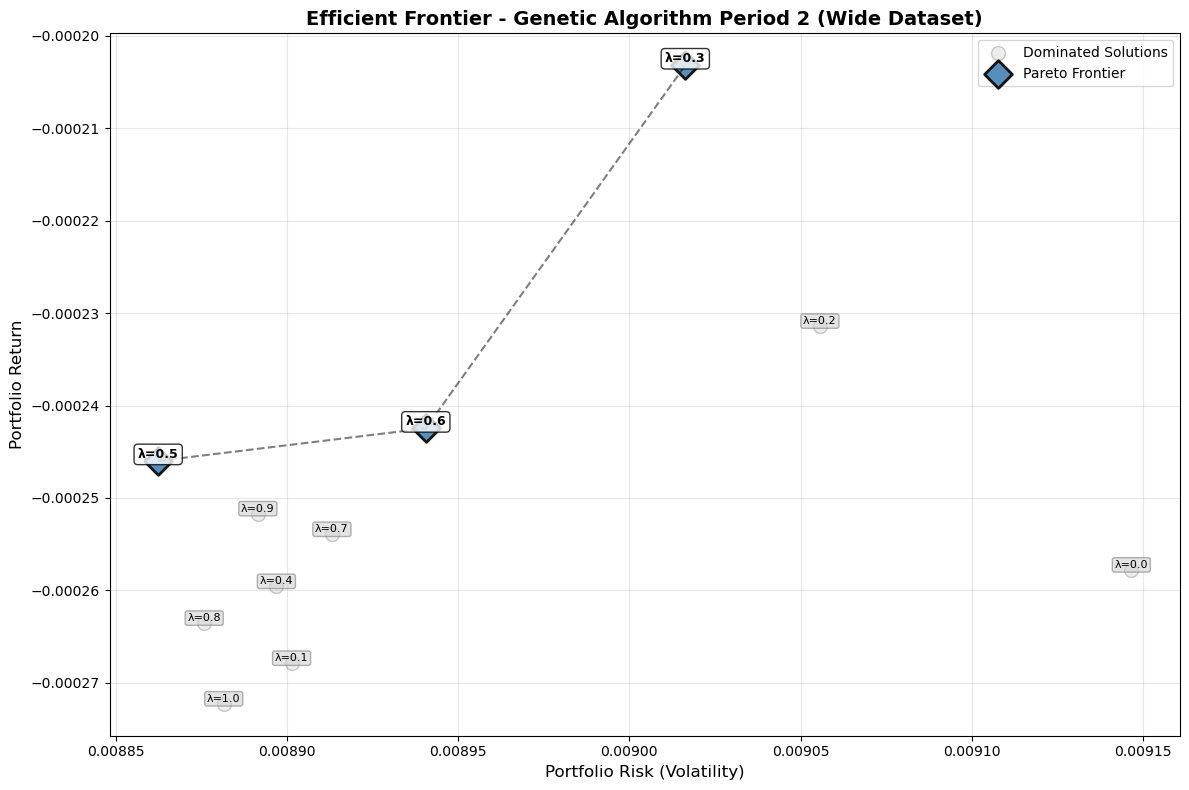


Pareto Frontier Summary:
Total solutions evaluated: 11
Pareto-optimal solutions: 3
Efficiency: 27.3%

Pareto Solutions:
Risk Level   Return       Risk         Sharpe      
------------------------------------------------------------
0.500        -0.000246    0.008862     -0.0278     
0.600        -0.000242    0.008941     -0.0271     
0.300        -0.000203    0.009016     -0.0225     

PERIOD 3 - Genetic Algorithm (Wide Dataset)
Loading existing results for period 3...


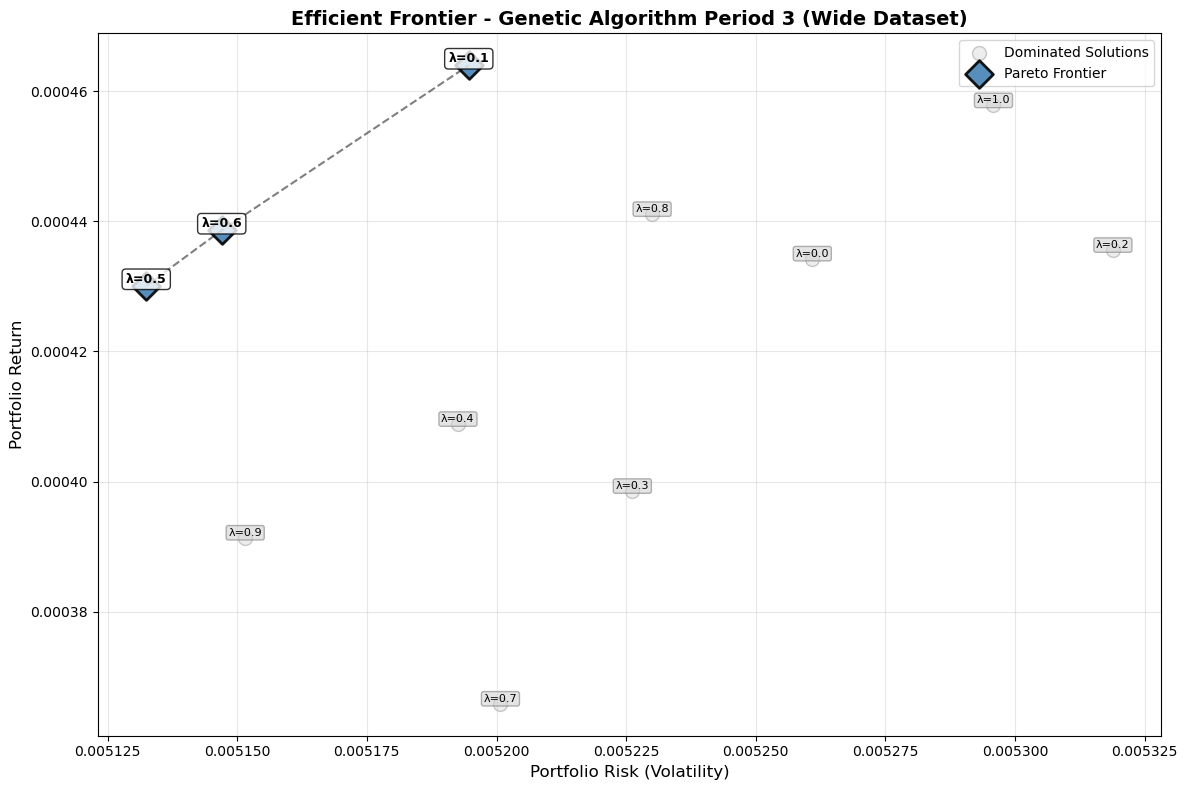


Pareto Frontier Summary:
Total solutions evaluated: 11
Pareto-optimal solutions: 3
Efficiency: 27.3%

Pareto Solutions:
Risk Level   Return       Risk         Sharpe      
------------------------------------------------------------
0.500        0.000430     0.005132     0.0838      
0.600        0.000439     0.005147     0.0852      
0.100        0.000464     0.005195     0.0893      

PERIOD 4 - Genetic Algorithm (Wide Dataset)
Loading existing results for period 4...


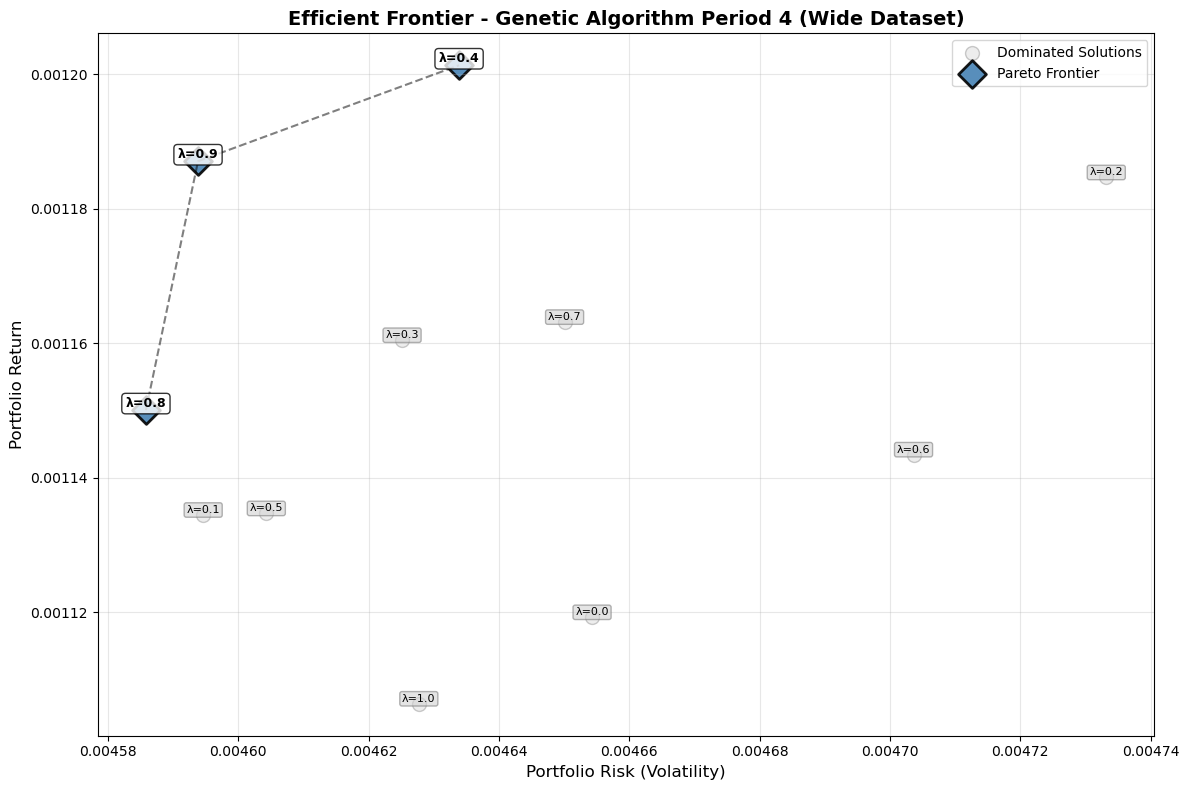


Pareto Frontier Summary:
Total solutions evaluated: 11
Pareto-optimal solutions: 3
Efficiency: 27.3%

Pareto Solutions:
Risk Level   Return       Risk         Sharpe      
------------------------------------------------------------
0.800        0.001150     0.004586     0.2508      
0.900        0.001187     0.004594     0.2584      
0.400        0.001201     0.004634     0.2593      

PERIOD 5 - Genetic Algorithm (Wide Dataset)
Loading existing results for period 5...


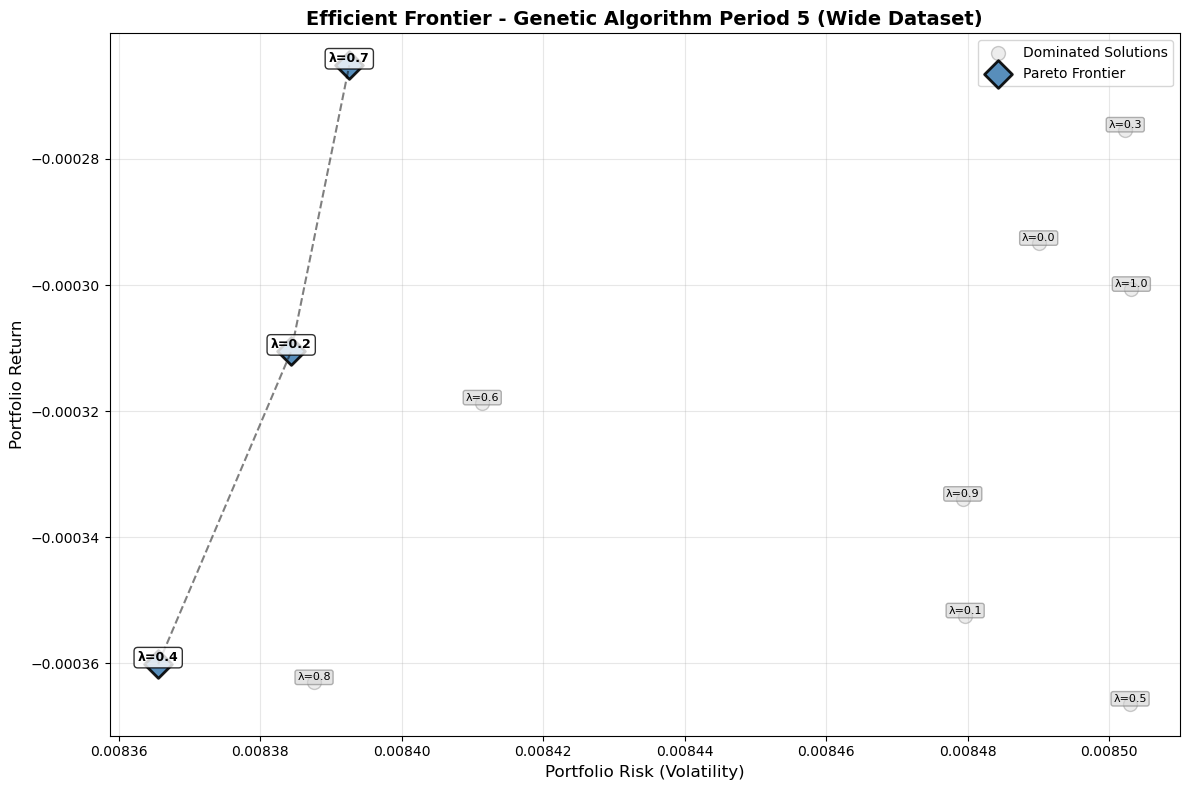


Pareto Frontier Summary:
Total solutions evaluated: 11
Pareto-optimal solutions: 3
Efficiency: 27.3%

Pareto Solutions:
Risk Level   Return       Risk         Sharpe      
------------------------------------------------------------
0.400        -0.000360    0.008366     -0.0430     
0.200        -0.000311    0.008384     -0.0370     
0.700        -0.000265    0.008393     -0.0316     

PERIOD 6 - Genetic Algorithm (Wide Dataset)
Loading existing results for period 6...


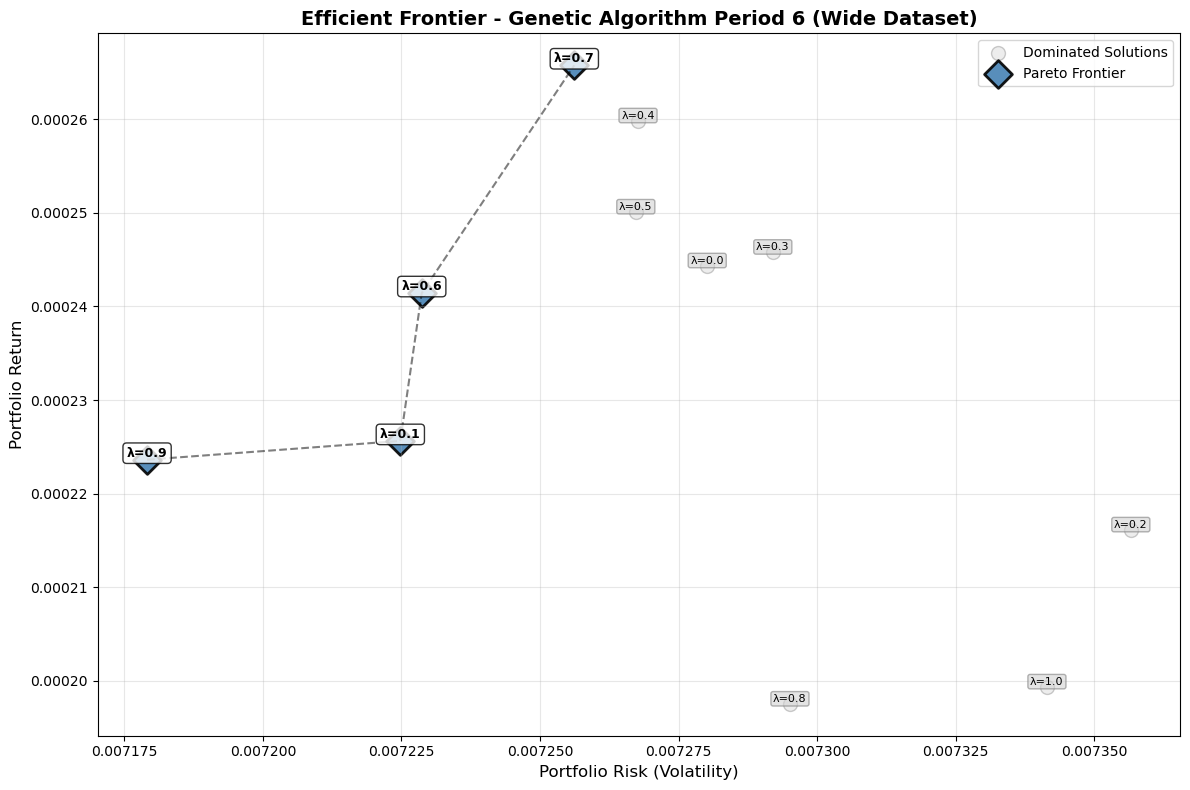


Pareto Frontier Summary:
Total solutions evaluated: 11
Pareto-optimal solutions: 4
Efficiency: 36.4%

Pareto Solutions:
Risk Level   Return       Risk         Sharpe      
------------------------------------------------------------
0.900        0.000224     0.007179     0.0312      
0.100        0.000226     0.007225     0.0312      
0.600        0.000241     0.007229     0.0334      
0.700        0.000266     0.007256     0.0366      

PERIOD 7 - Genetic Algorithm (Wide Dataset)
Loading existing results for period 7...


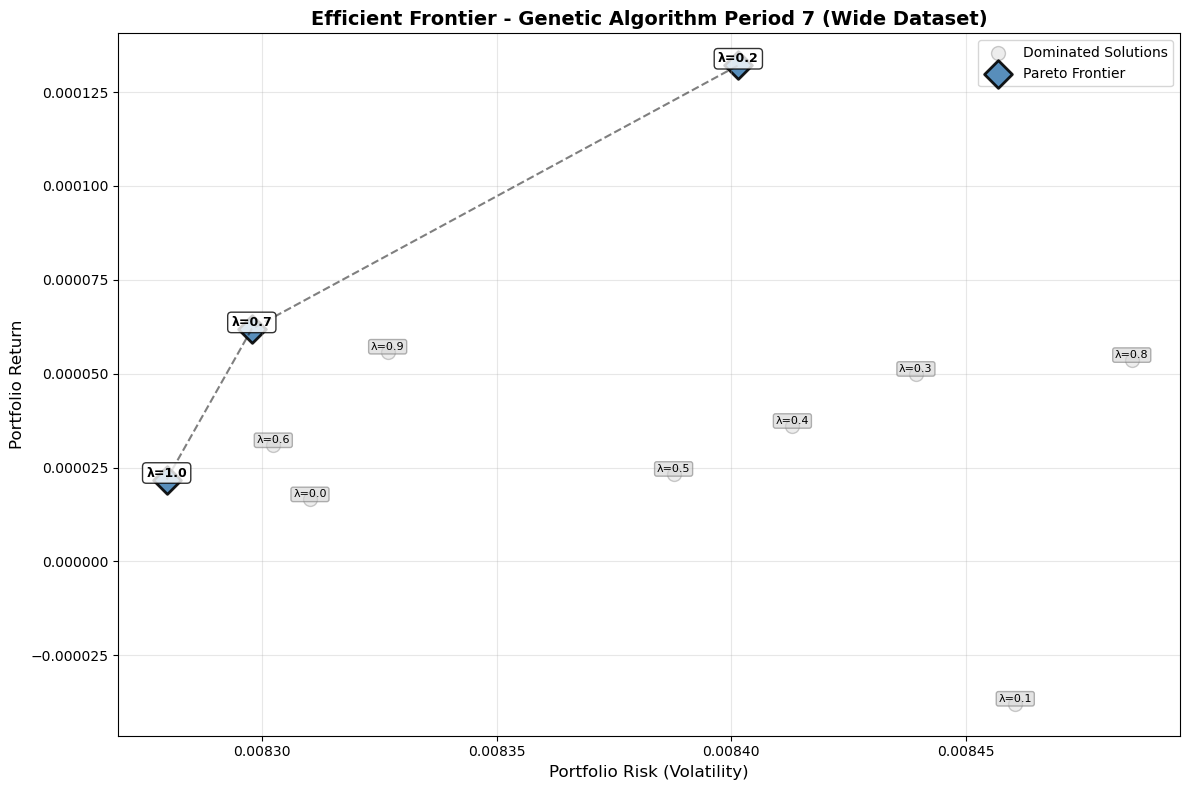


Pareto Frontier Summary:
Total solutions evaluated: 11
Pareto-optimal solutions: 3
Efficiency: 27.3%

Pareto Solutions:
Risk Level   Return       Risk         Sharpe      
------------------------------------------------------------
1.000        0.000022     0.008280     0.0026      
0.700        0.000062     0.008298     0.0075      
0.200        0.000132     0.008402     0.0157      

PERIOD 8 - Genetic Algorithm (Wide Dataset)
Loading existing results for period 8...


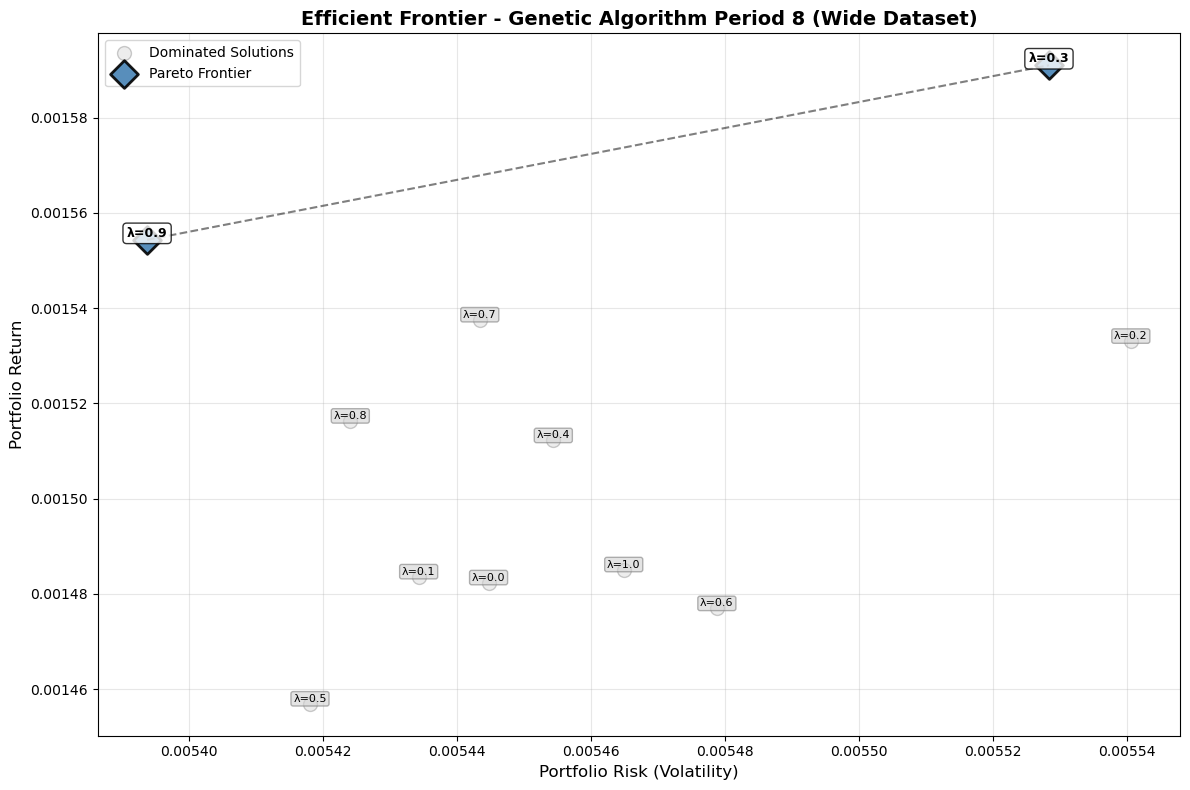


Pareto Frontier Summary:
Total solutions evaluated: 11
Pareto-optimal solutions: 2
Efficiency: 18.2%

Pareto Solutions:
Risk Level   Return       Risk         Sharpe      
------------------------------------------------------------
0.900        0.001554     0.005394     0.2882      
0.300        0.001591     0.005528     0.2878      

PERIOD 9 - Genetic Algorithm (Wide Dataset)
Loading existing results for period 9...


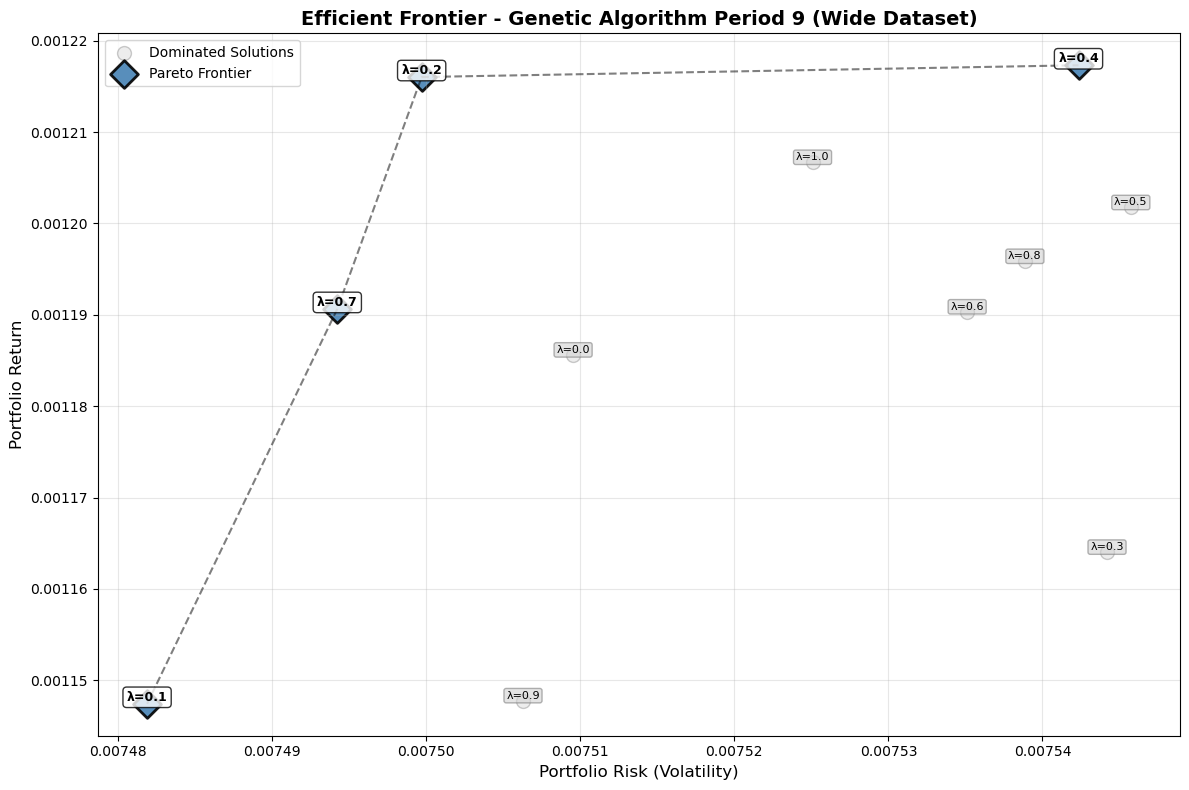


Pareto Frontier Summary:
Total solutions evaluated: 11
Pareto-optimal solutions: 4
Efficiency: 36.4%

Pareto Solutions:
Risk Level   Return       Risk         Sharpe      
------------------------------------------------------------
0.100        0.001147     0.007482     0.1534      
0.700        0.001191     0.007494     0.1589      
0.200        0.001216     0.007500     0.1621      
0.400        0.001217     0.007542     0.1614      

Genetic Algorithm - Wide Dataset Complete


In [12]:
for period in range(parameters['n_periods']):
    run_pareto_optimization_period(
        period=period,
        solver_name='Genetic Algorithm',
        solver_key='ga',
        optimization_function=genetic_algorithm_qubo,
        data=source_wide,
        benchmark=benchmark,
        results_dict=all_periods_results_wide['genetic_algorithm'],
        parameters=parameters,
        results_base_path=results_base_path,
        population_size=parameters['population_size'],
        num_generations=parameters['num_generations'],
        mutation_rate=parameters['mutation_rate'],
        elitism=parameters['elitism']
    )

print(f"\n{'='*80}")
print("Genetic Algorithm - Wide Dataset Complete")
print(f"{'='*80}")

### SciPy SLSQP - Wide Dataset (All Periods)


PERIOD 0 - SciPy SLSQP (Wide Dataset)
Loading existing results for period 0...


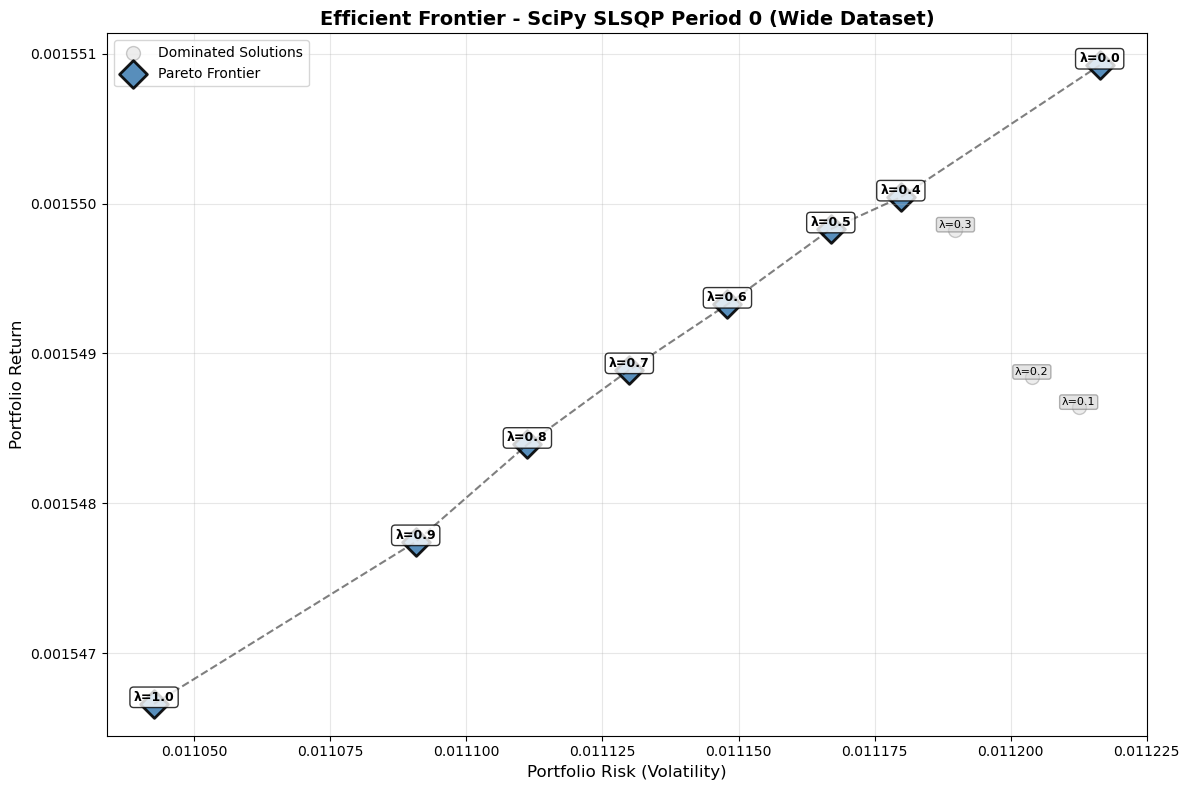


Pareto Frontier Summary:
Total solutions evaluated: 11
Pareto-optimal solutions: 8
Efficiency: 72.7%

Pareto Solutions:
Risk Level   Return       Risk         Sharpe      
------------------------------------------------------------
1.000        0.001547     0.011043     0.1401      
0.900        0.001548     0.011091     0.1396      
0.800        0.001548     0.011111     0.1394      
0.700        0.001549     0.011130     0.1392      
0.600        0.001549     0.011148     0.1390      
0.500        0.001550     0.011167     0.1388      
0.400        0.001550     0.011180     0.1386      
0.000        0.001551     0.011216     0.1383      

PERIOD 1 - SciPy SLSQP (Wide Dataset)
Loading existing results for period 1...


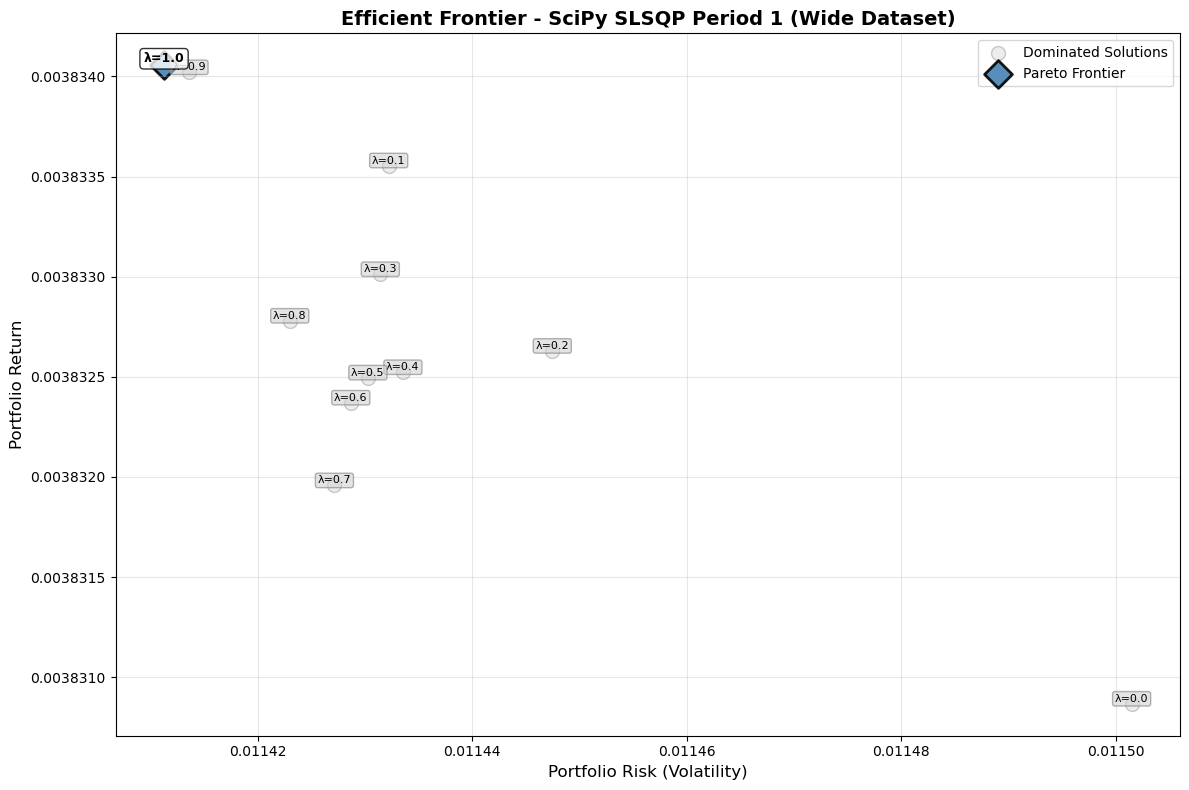


Pareto Frontier Summary:
Total solutions evaluated: 11
Pareto-optimal solutions: 1
Efficiency: 9.1%

Pareto Solutions:
Risk Level   Return       Risk         Sharpe      
------------------------------------------------------------
1.000        0.003834     0.011411     0.3360      

PERIOD 2 - SciPy SLSQP (Wide Dataset)
Loading existing results for period 2...


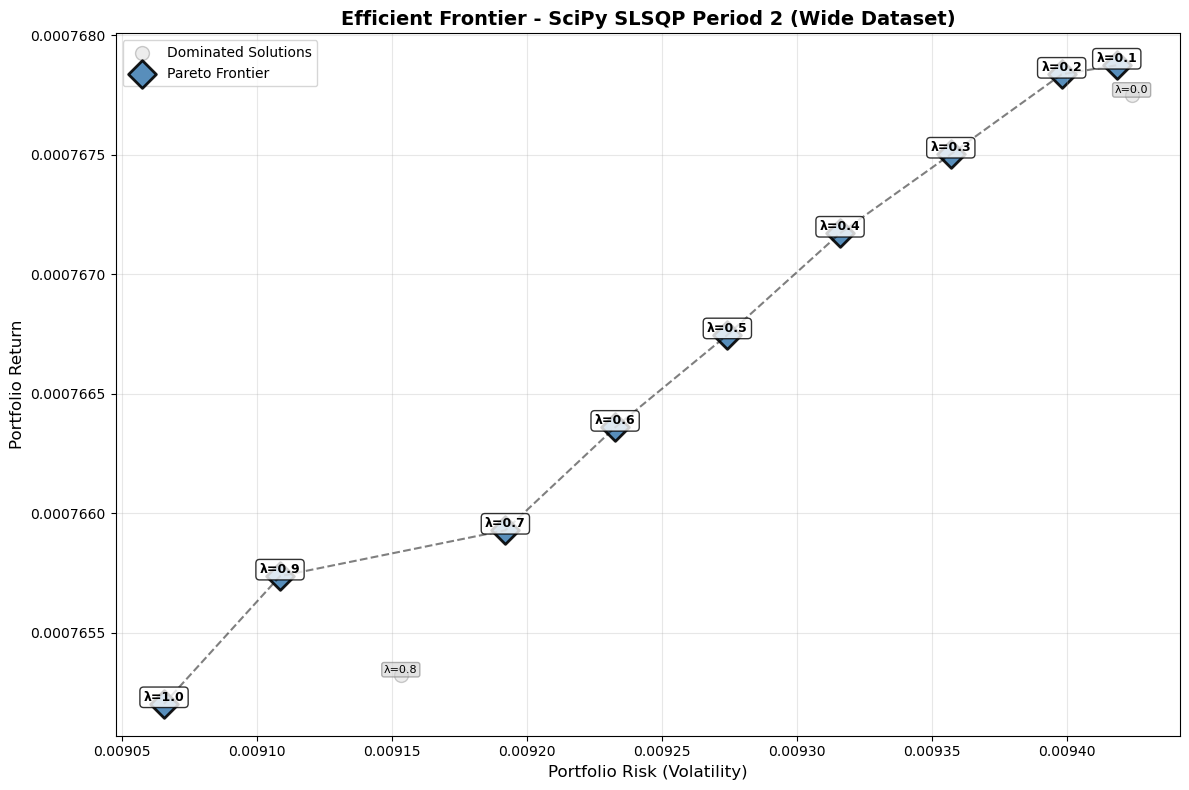


Pareto Frontier Summary:
Total solutions evaluated: 11
Pareto-optimal solutions: 9
Efficiency: 81.8%

Pareto Solutions:
Risk Level   Return       Risk         Sharpe      
------------------------------------------------------------
1.000        0.000765     0.009066     0.0844      
0.900        0.000766     0.009108     0.0841      
0.700        0.000766     0.009192     0.0833      
0.600        0.000766     0.009233     0.0830      
0.500        0.000767     0.009274     0.0827      
0.400        0.000767     0.009316     0.0824      
0.300        0.000768     0.009357     0.0820      
0.200        0.000768     0.009398     0.0817      
0.100        0.000768     0.009418     0.0815      

PERIOD 3 - SciPy SLSQP (Wide Dataset)
Loading existing results for period 3...


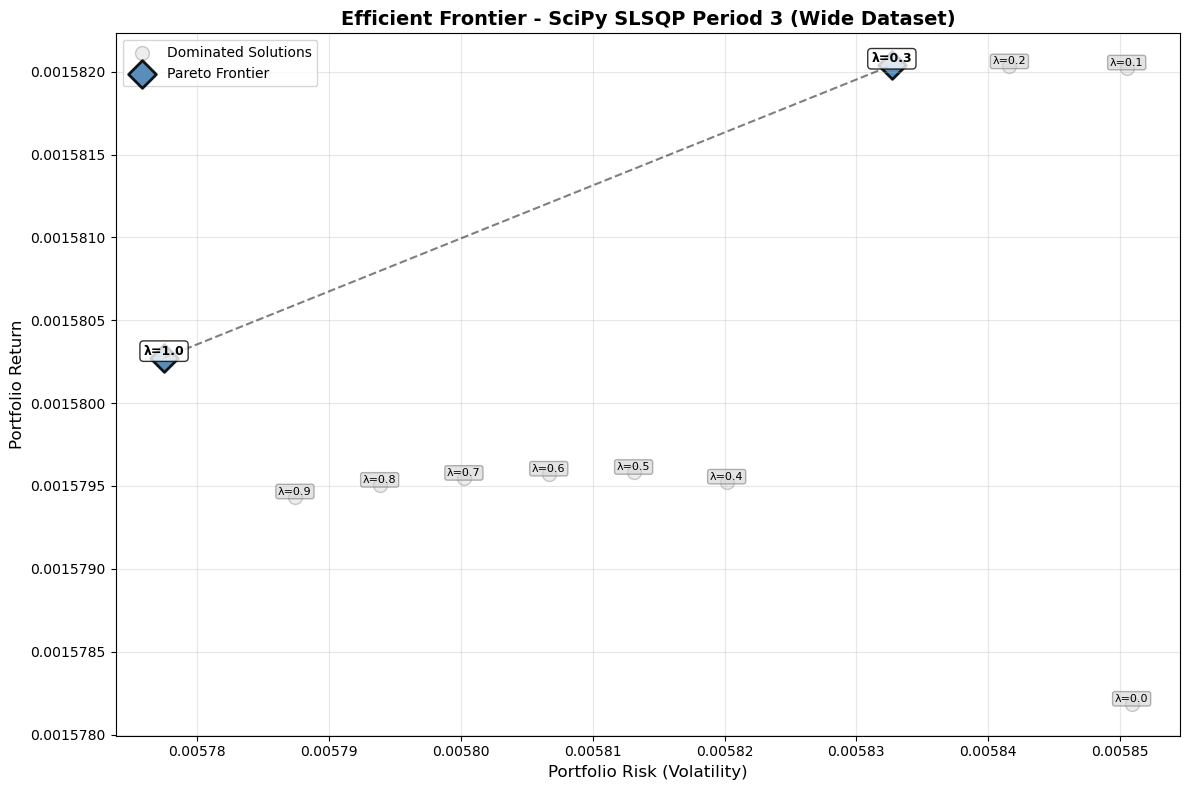


Pareto Frontier Summary:
Total solutions evaluated: 11
Pareto-optimal solutions: 2
Efficiency: 18.2%

Pareto Solutions:
Risk Level   Return       Risk         Sharpe      
------------------------------------------------------------
1.000        0.001580     0.005777     0.2735      
0.300        0.001582     0.005833     0.2712      

PERIOD 4 - SciPy SLSQP (Wide Dataset)
Loading existing results for period 4...


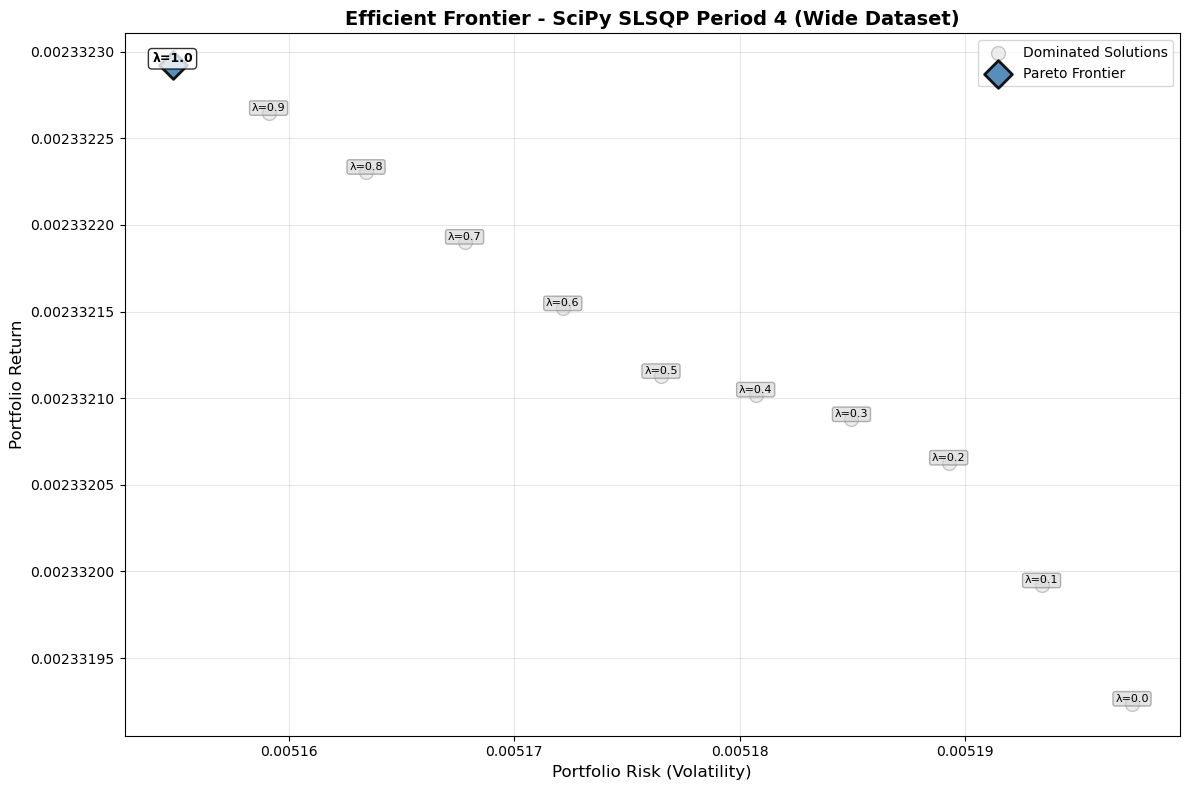


Pareto Frontier Summary:
Total solutions evaluated: 11
Pareto-optimal solutions: 1
Efficiency: 9.1%

Pareto Solutions:
Risk Level   Return       Risk         Sharpe      
------------------------------------------------------------
1.000        0.002332     0.005155     0.4524      

PERIOD 5 - SciPy SLSQP (Wide Dataset)
Loading existing results for period 5...


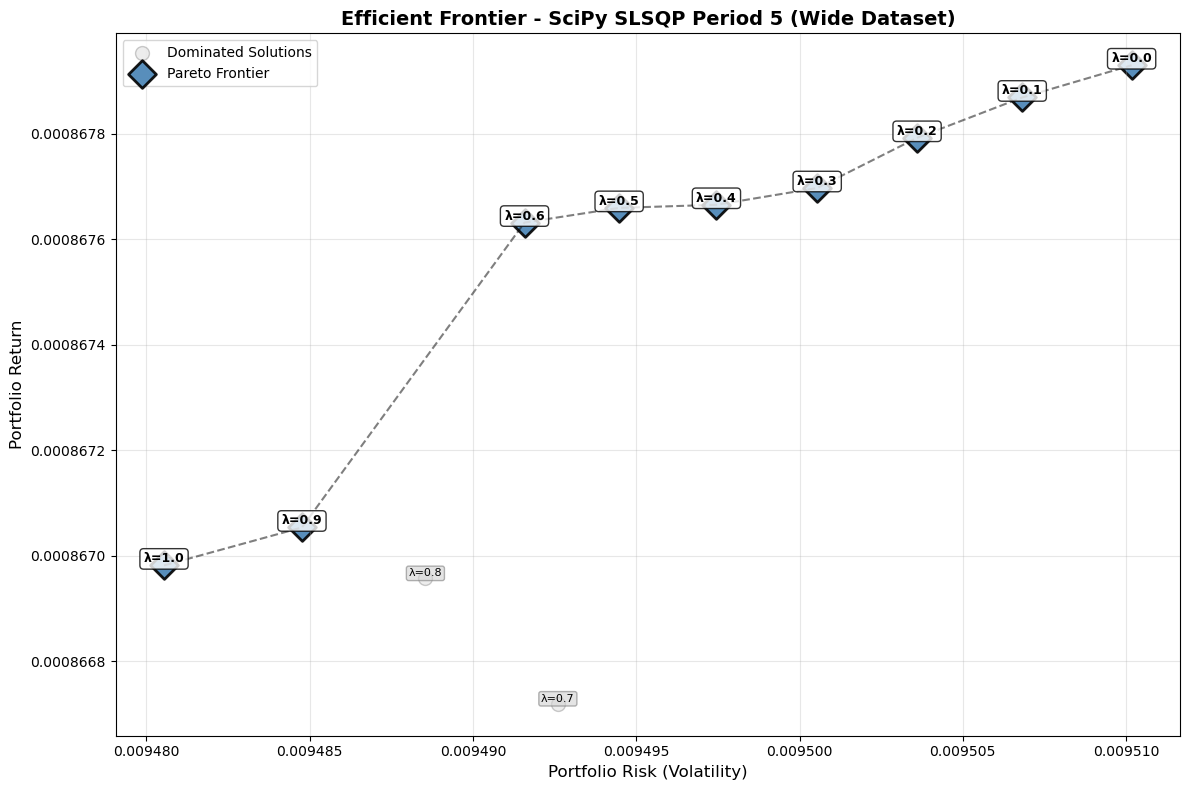


Pareto Frontier Summary:
Total solutions evaluated: 11
Pareto-optimal solutions: 9
Efficiency: 81.8%

Pareto Solutions:
Risk Level   Return       Risk         Sharpe      
------------------------------------------------------------
1.000        0.000867     0.009481     0.0914      
0.900        0.000867     0.009485     0.0914      
0.600        0.000868     0.009492     0.0914      
0.500        0.000868     0.009494     0.0914      
0.400        0.000868     0.009497     0.0914      
0.300        0.000868     0.009501     0.0913      
0.200        0.000868     0.009504     0.0913      
0.100        0.000868     0.009507     0.0913      
0.000        0.000868     0.009510     0.0913      

PERIOD 6 - SciPy SLSQP (Wide Dataset)
Loading existing results for period 6...


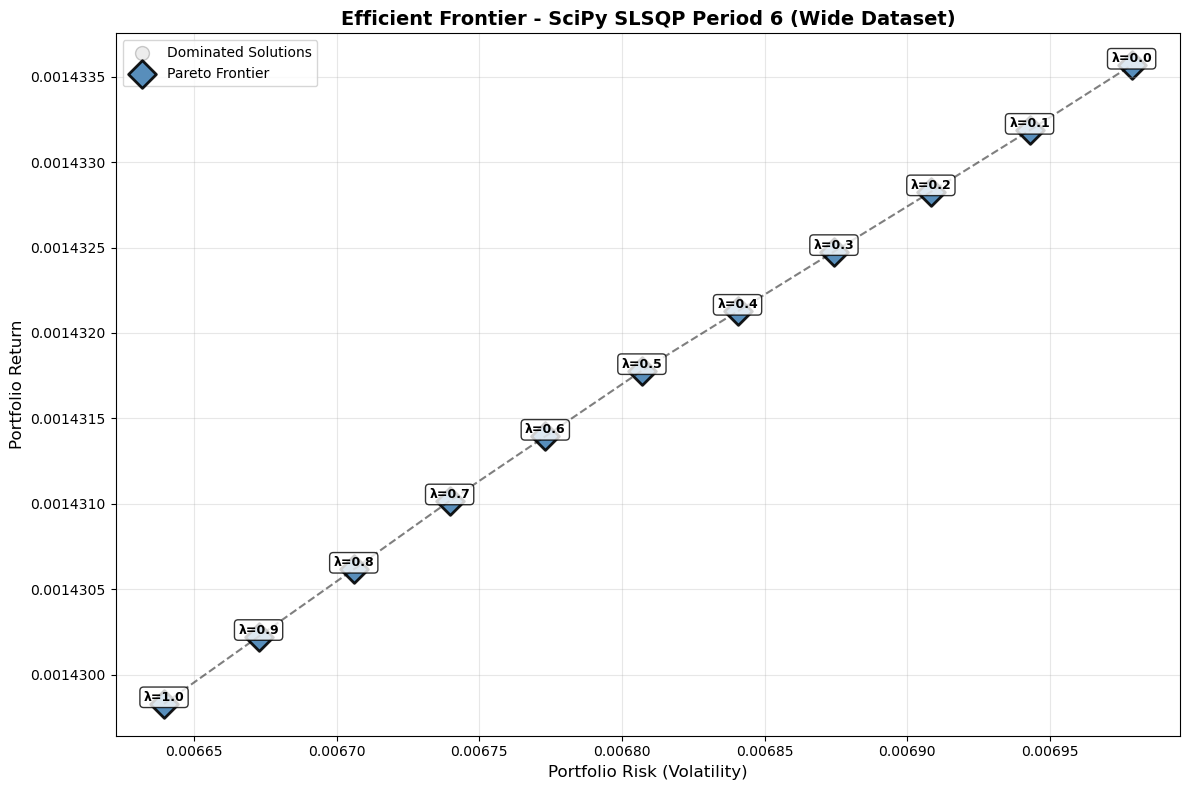


Pareto Frontier Summary:
Total solutions evaluated: 11
Pareto-optimal solutions: 11
Efficiency: 100.0%

Pareto Solutions:
Risk Level   Return       Risk         Sharpe      
------------------------------------------------------------
1.000        0.001430     0.006639     0.2154      
0.900        0.001430     0.006673     0.2143      
0.800        0.001431     0.006706     0.2133      
0.700        0.001431     0.006740     0.2123      
0.600        0.001431     0.006773     0.2113      
0.500        0.001432     0.006807     0.2103      
0.400        0.001432     0.006840     0.2094      
0.300        0.001432     0.006874     0.2084      
0.200        0.001433     0.006908     0.2074      
0.100        0.001433     0.006943     0.2064      
0.000        0.001434     0.006979     0.2054      

PERIOD 7 - SciPy SLSQP (Wide Dataset)
Loading existing results for period 7...


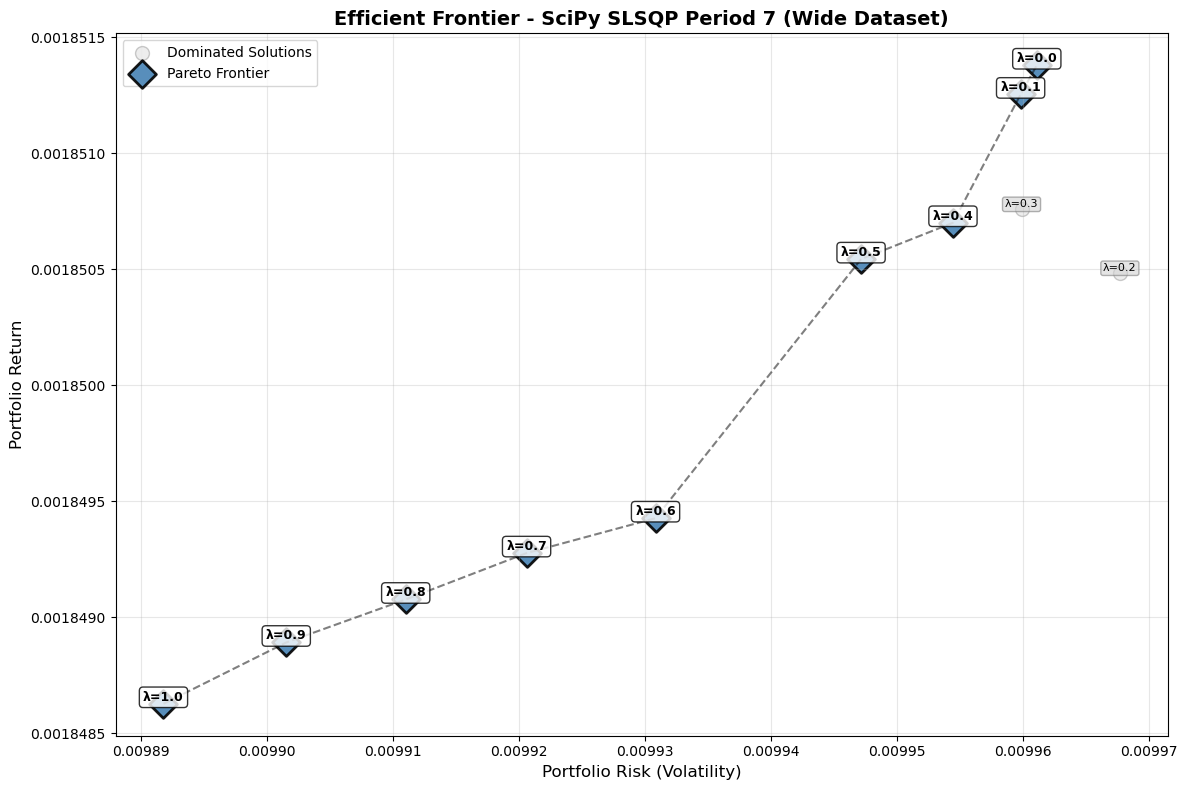


Pareto Frontier Summary:
Total solutions evaluated: 11
Pareto-optimal solutions: 9
Efficiency: 81.8%

Pareto Solutions:
Risk Level   Return       Risk         Sharpe      
------------------------------------------------------------
1.000        0.001849     0.009892     0.1869      
0.900        0.001849     0.009902     0.1867      
0.800        0.001849     0.009911     0.1866      
0.700        0.001849     0.009921     0.1864      
0.600        0.001849     0.009931     0.1862      
0.500        0.001851     0.009947     0.1860      
0.400        0.001851     0.009954     0.1859      
0.100        0.001851     0.009960     0.1859      
0.000        0.001851     0.009961     0.1859      

PERIOD 8 - SciPy SLSQP (Wide Dataset)
Loading existing results for period 8...


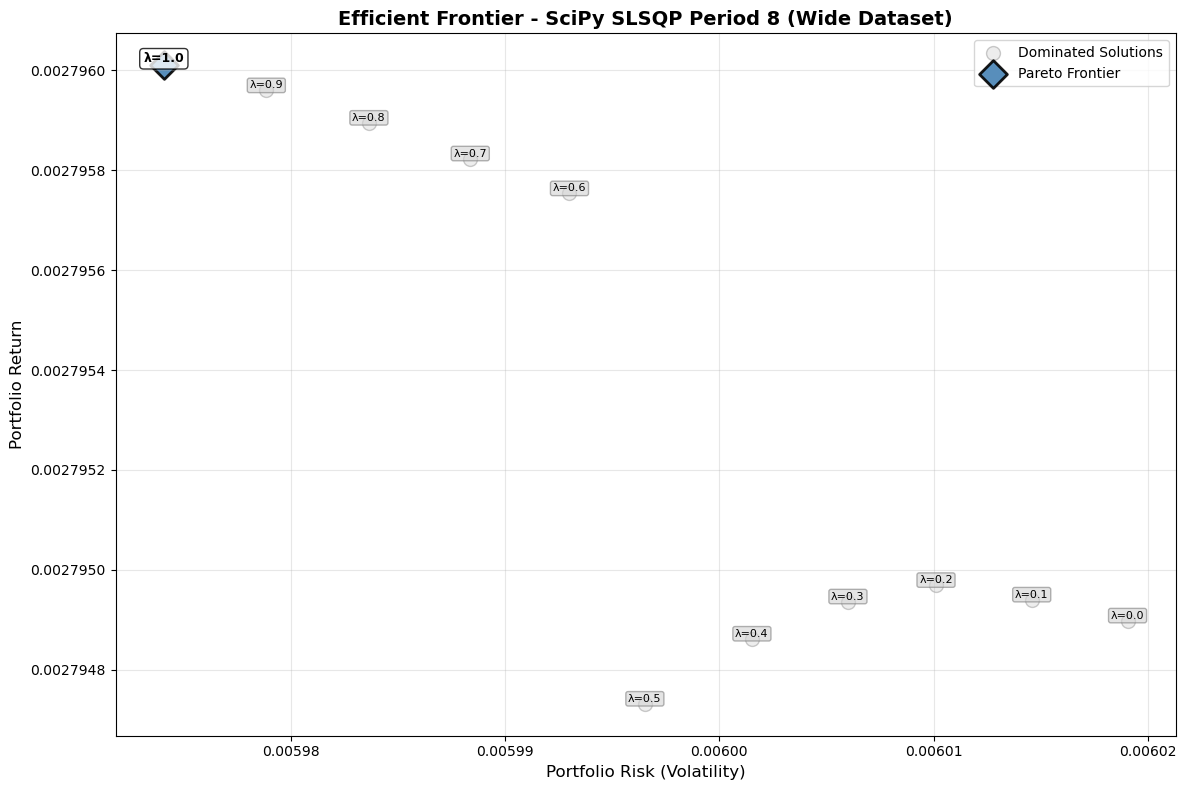


Pareto Frontier Summary:
Total solutions evaluated: 11
Pareto-optimal solutions: 1
Efficiency: 9.1%

Pareto Solutions:
Risk Level   Return       Risk         Sharpe      
------------------------------------------------------------
1.000        0.002796     0.005974     0.4680      

PERIOD 9 - SciPy SLSQP (Wide Dataset)
Loading existing results for period 9...


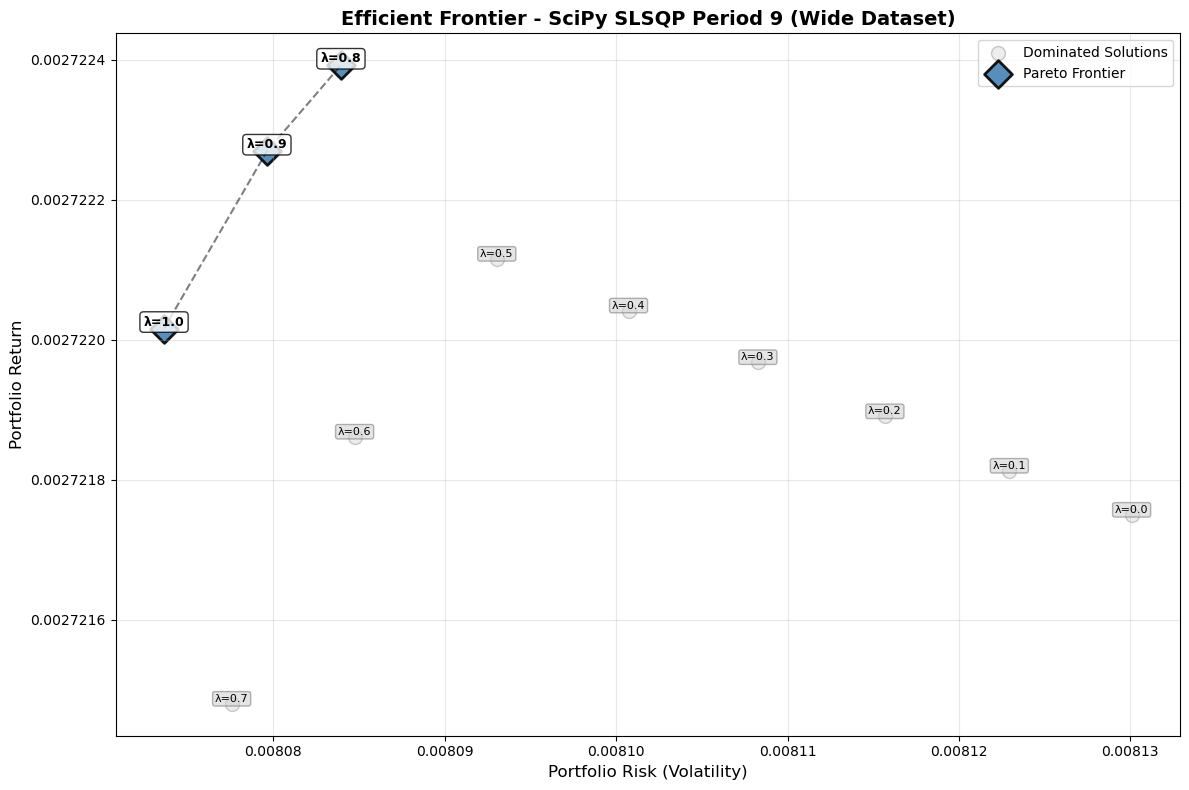


Pareto Frontier Summary:
Total solutions evaluated: 11
Pareto-optimal solutions: 3
Efficiency: 27.3%

Pareto Solutions:
Risk Level   Return       Risk         Sharpe      
------------------------------------------------------------
1.000        0.002722     0.008074     0.3371      
0.900        0.002722     0.008080     0.3369      
0.800        0.002722     0.008084     0.3368      

SciPy SLSQP - Wide Dataset Complete


In [13]:
for period in range(parameters['n_periods']):
    run_pareto_optimization_period(
        period=period,
        solver_name='SciPy SLSQP',
        solver_key='slsqp',
        optimization_function=scipy_slsqp_qubo,
        data=source_wide,
        benchmark=benchmark,
        results_dict=all_periods_results_wide['scipy_slsqp'],
        parameters=parameters,
        results_base_path=results_base_path
    )

print(f"\n{'='*80}")
print("SciPy SLSQP - Wide Dataset Complete")
print(f"{'='*80}")

### Riskfolio - Wide Dataset (All Periods)


PERIOD 0 - Riskfolio (Wide Dataset)
Loading existing results for period 0...


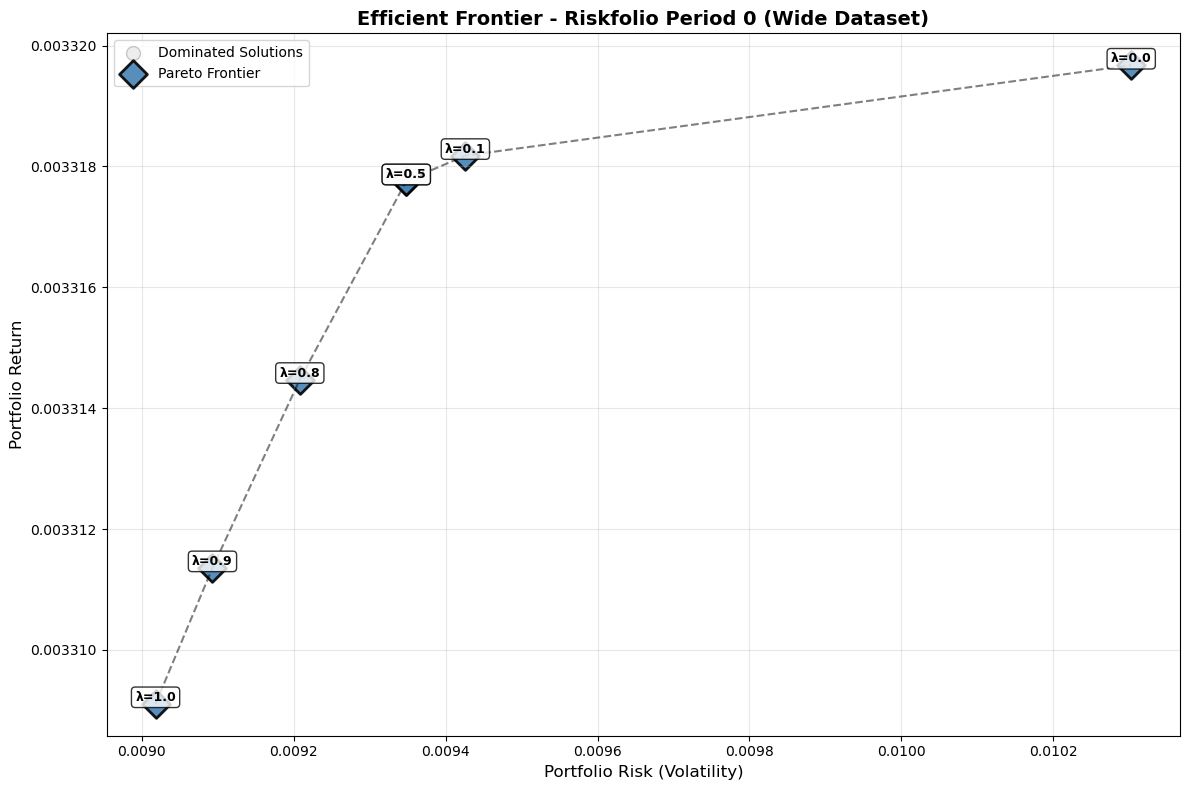


Pareto Frontier Summary:
Total solutions evaluated: 11
Pareto-optimal solutions: 7
Efficiency: 63.6%

Pareto Solutions:
Risk Level   Return       Risk         Sharpe      
------------------------------------------------------------
1.000        0.003309     0.009018     0.3669      
0.900        0.003311     0.009093     0.3642      
0.800        0.003314     0.009208     0.3600      
0.700        0.003318     0.009348     0.3549      
0.500        0.003318     0.009348     0.3549      
0.100        0.003318     0.009426     0.3520      
0.000        0.003320     0.010303     0.3222      

PERIOD 1 - Riskfolio (Wide Dataset)
Loading existing results for period 1...


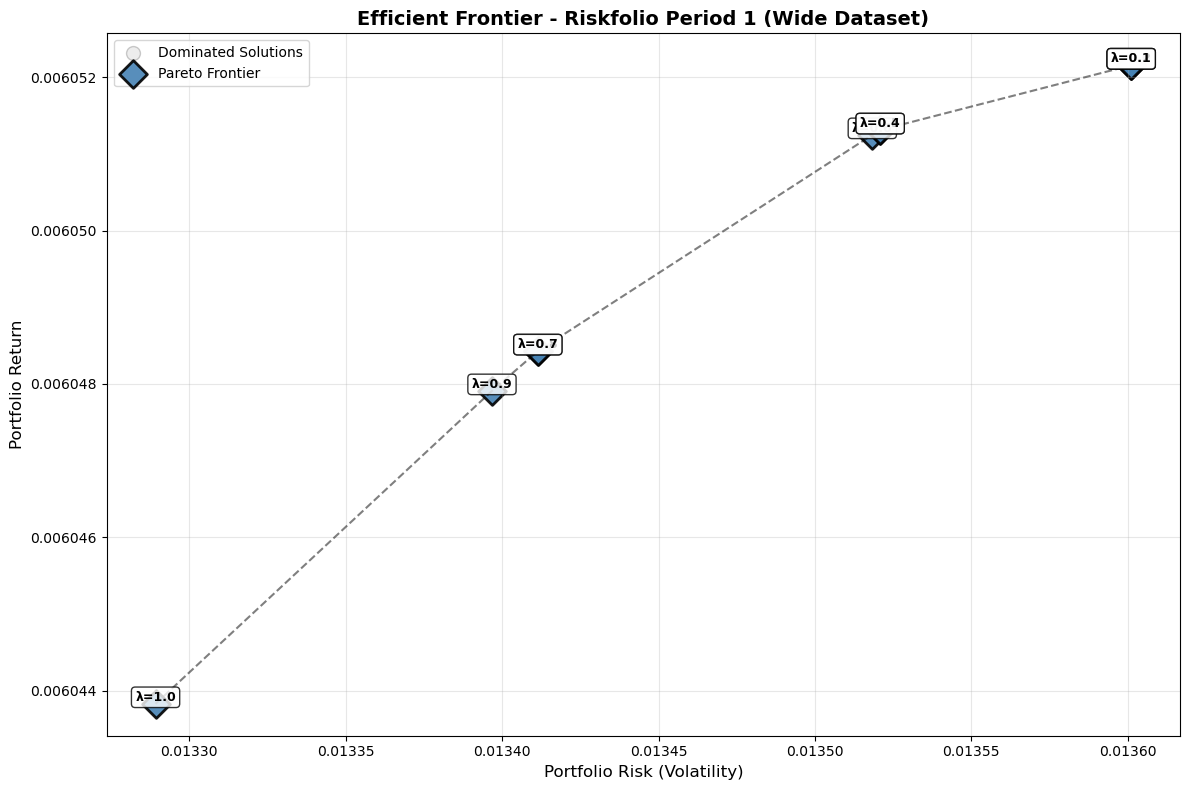


Pareto Frontier Summary:
Total solutions evaluated: 11
Pareto-optimal solutions: 10
Efficiency: 90.9%

Pareto Solutions:
Risk Level   Return       Risk         Sharpe      
------------------------------------------------------------
1.000        0.006044     0.013289     0.4548      
0.900        0.006048     0.013397     0.4514      
0.800        0.006048     0.013411     0.4510      
0.700        0.006048     0.013411     0.4510      
0.600        0.006051     0.013518     0.4476      
0.500        0.006051     0.013521     0.4476      
0.400        0.006051     0.013521     0.4476      
0.000        0.006052     0.013601     0.4450      
0.200        0.006052     0.013601     0.4450      
0.100        0.006052     0.013601     0.4450      

PERIOD 2 - Riskfolio (Wide Dataset)
Loading existing results for period 2...


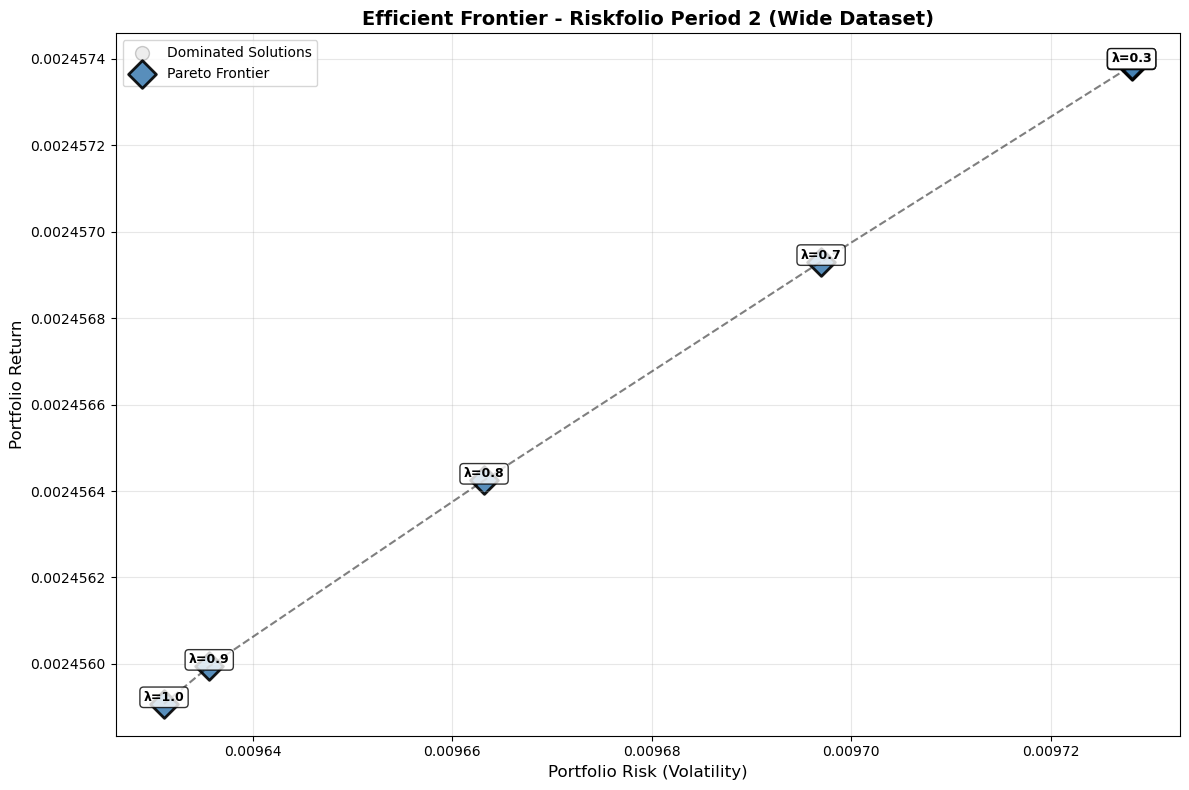


Pareto Frontier Summary:
Total solutions evaluated: 11
Pareto-optimal solutions: 7
Efficiency: 63.6%

Pareto Solutions:
Risk Level   Return       Risk         Sharpe      
------------------------------------------------------------
1.000        0.002456     0.009631     0.2550      
0.900        0.002456     0.009636     0.2549      
0.800        0.002456     0.009663     0.2542      
0.700        0.002457     0.009697     0.2534      
0.600        0.002457     0.009728     0.2526      
0.500        0.002457     0.009728     0.2526      
0.300        0.002457     0.009728     0.2526      

PERIOD 3 - Riskfolio (Wide Dataset)
Loading existing results for period 3...


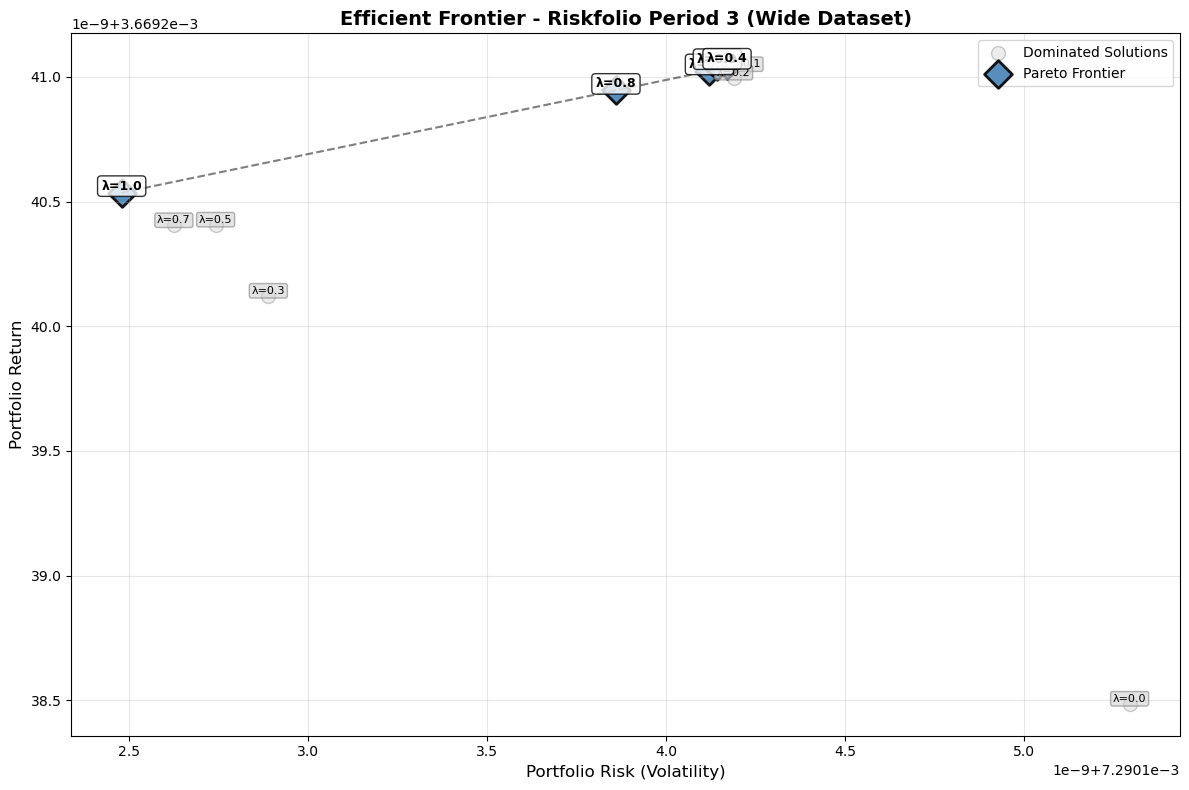


Pareto Frontier Summary:
Total solutions evaluated: 11
Pareto-optimal solutions: 5
Efficiency: 45.5%

Pareto Solutions:
Risk Level   Return       Risk         Sharpe      
------------------------------------------------------------
1.000        0.003669     0.007290     0.5033      
0.800        0.003669     0.007290     0.5033      
0.600        0.003669     0.007290     0.5033      
0.900        0.003669     0.007290     0.5033      
0.400        0.003669     0.007290     0.5033      

PERIOD 4 - Riskfolio (Wide Dataset)
Loading existing results for period 4...


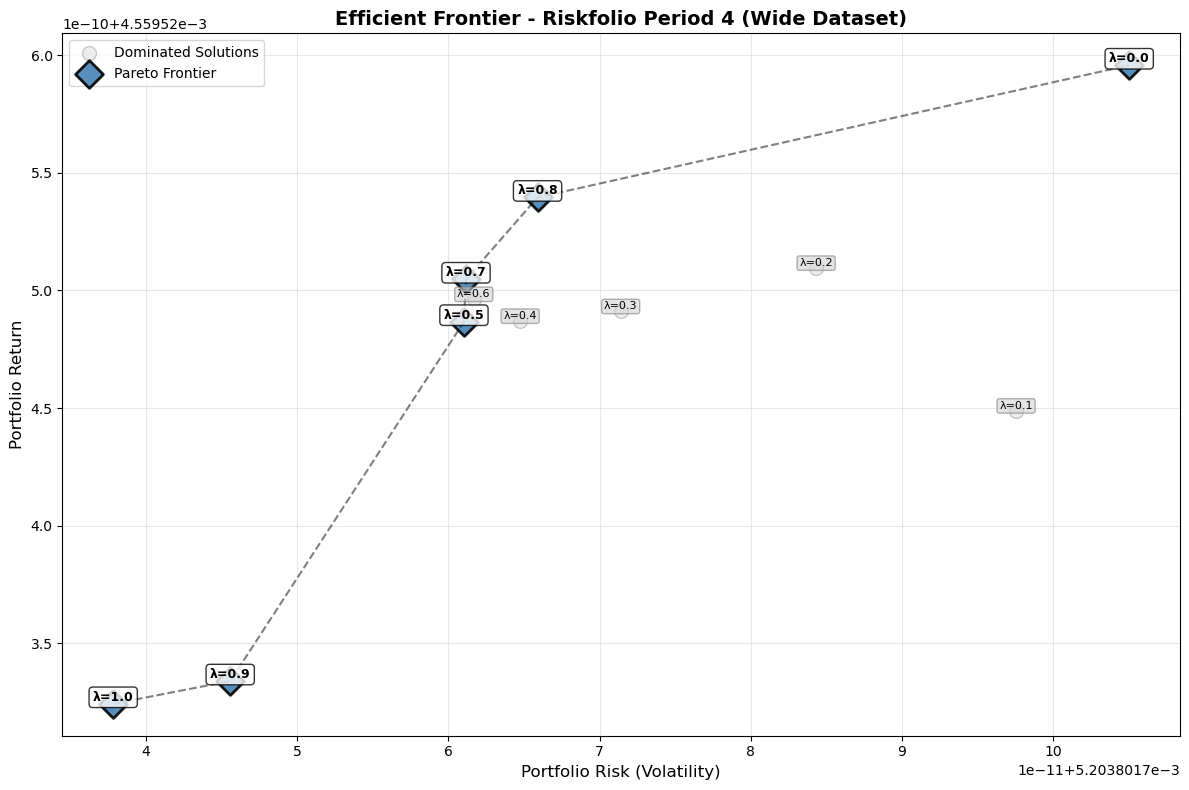


Pareto Frontier Summary:
Total solutions evaluated: 11
Pareto-optimal solutions: 6
Efficiency: 54.5%

Pareto Solutions:
Risk Level   Return       Risk         Sharpe      
------------------------------------------------------------
1.000        0.004560     0.005204     0.8762      
0.900        0.004560     0.005204     0.8762      
0.500        0.004560     0.005204     0.8762      
0.700        0.004560     0.005204     0.8762      
0.800        0.004560     0.005204     0.8762      
0.000        0.004560     0.005204     0.8762      

PERIOD 5 - Riskfolio (Wide Dataset)
Loading existing results for period 5...


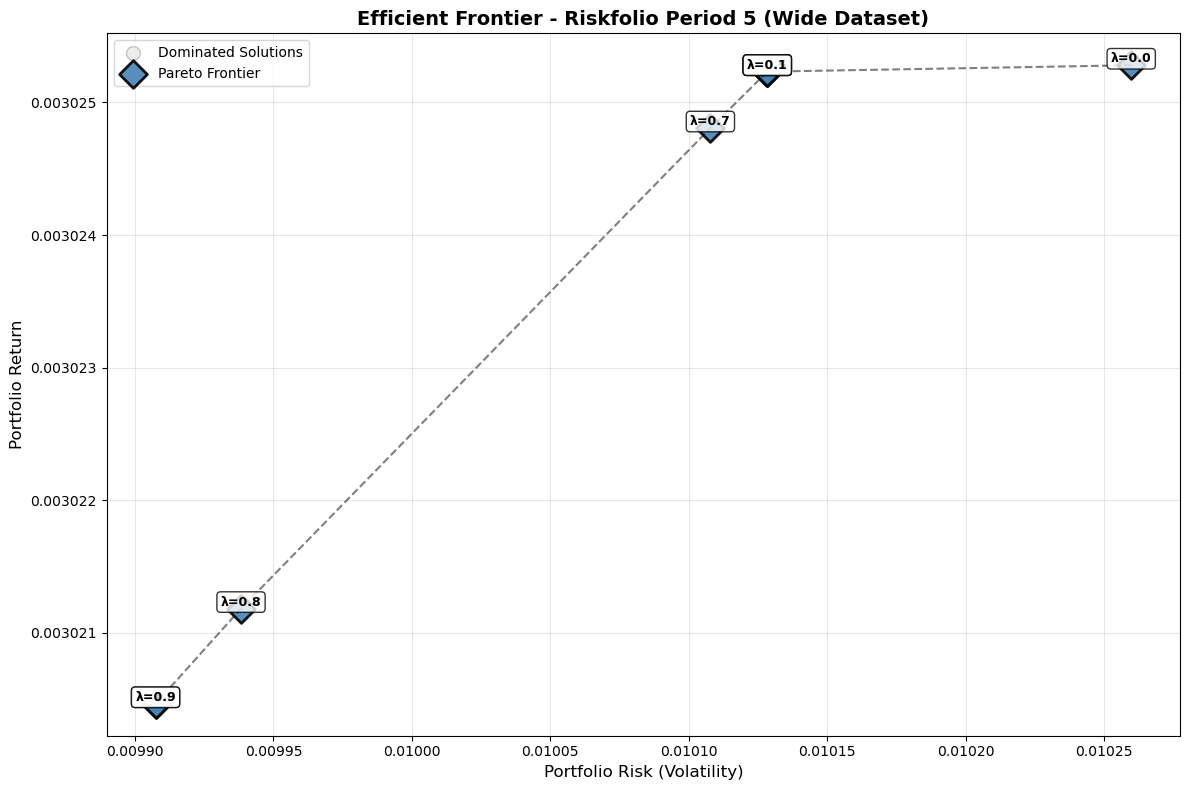


Pareto Frontier Summary:
Total solutions evaluated: 11
Pareto-optimal solutions: 9
Efficiency: 81.8%

Pareto Solutions:
Risk Level   Return       Risk         Sharpe      
------------------------------------------------------------
1.000        0.003020     0.009907     0.3049      
0.900        0.003020     0.009907     0.3049      
0.800        0.003021     0.009938     0.3040      
0.700        0.003025     0.010108     0.2993      
0.600        0.003025     0.010128     0.2987      
0.400        0.003025     0.010128     0.2987      
0.500        0.003025     0.010128     0.2987      
0.100        0.003025     0.010128     0.2987      
0.000        0.003025     0.010260     0.2949      

PERIOD 6 - Riskfolio (Wide Dataset)
Loading existing results for period 6...


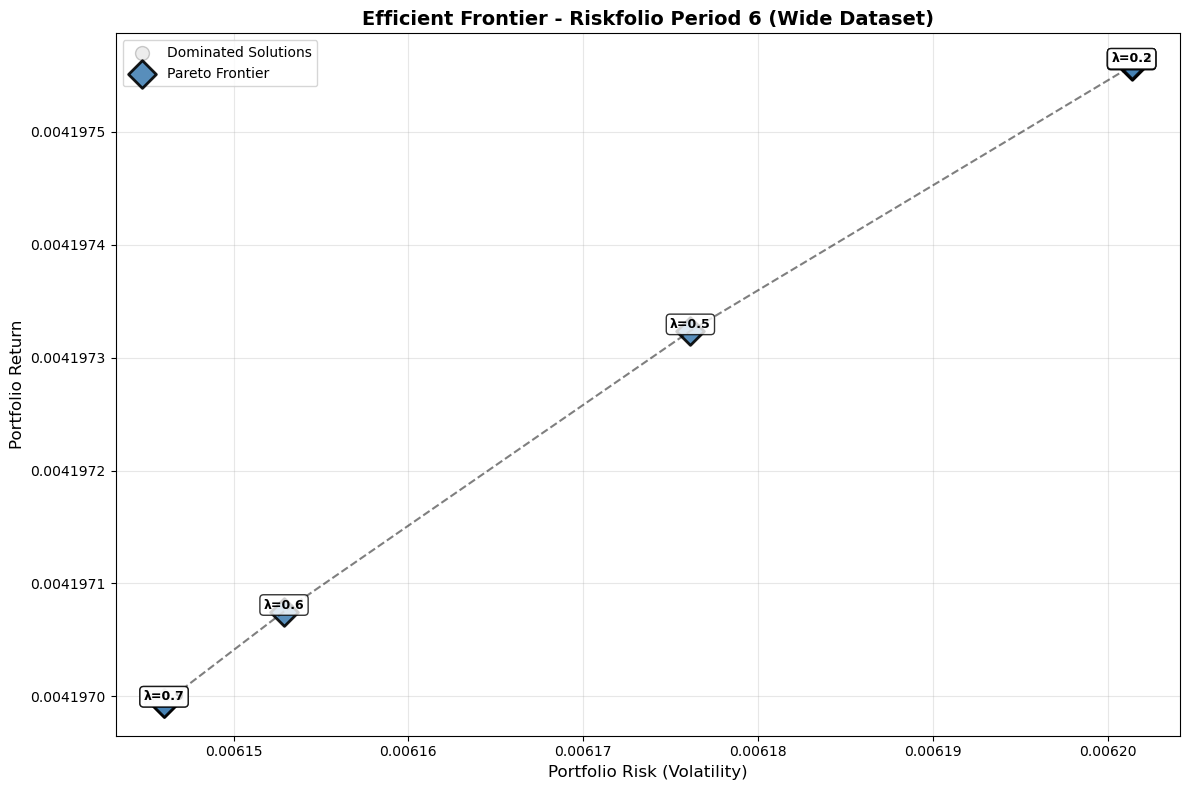


Pareto Frontier Summary:
Total solutions evaluated: 11
Pareto-optimal solutions: 8
Efficiency: 72.7%

Pareto Solutions:
Risk Level   Return       Risk         Sharpe      
------------------------------------------------------------
0.900        0.004197     0.006146     0.6829      
0.700        0.004197     0.006146     0.6829      
0.600        0.004197     0.006153     0.6821      
0.500        0.004197     0.006176     0.6796      
0.400        0.004198     0.006201     0.6769      
0.000        0.004198     0.006201     0.6769      
0.300        0.004198     0.006201     0.6769      
0.200        0.004198     0.006201     0.6769      

PERIOD 7 - Riskfolio (Wide Dataset)
Loading existing results for period 7...


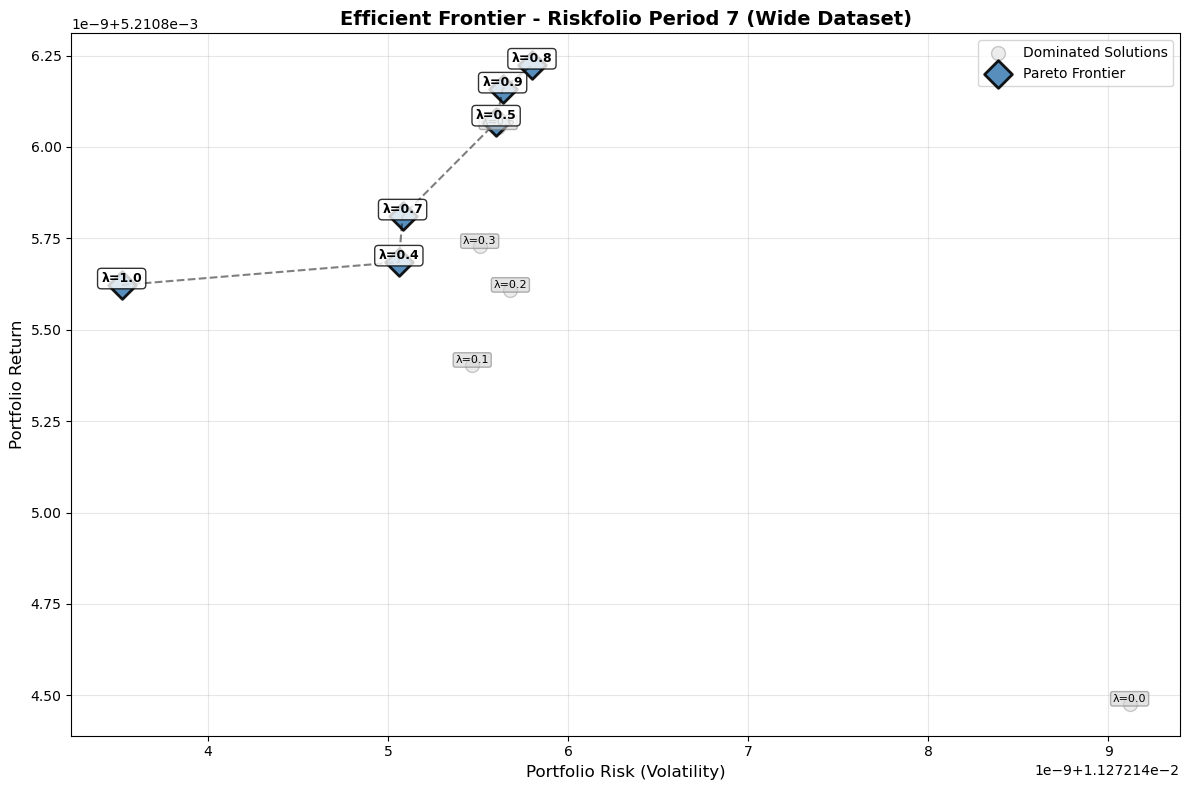


Pareto Frontier Summary:
Total solutions evaluated: 11
Pareto-optimal solutions: 6
Efficiency: 54.5%

Pareto Solutions:
Risk Level   Return       Risk         Sharpe      
------------------------------------------------------------
1.000        0.005211     0.011272     0.4623      
0.400        0.005211     0.011272     0.4623      
0.700        0.005211     0.011272     0.4623      
0.500        0.005211     0.011272     0.4623      
0.900        0.005211     0.011272     0.4623      
0.800        0.005211     0.011272     0.4623      

PERIOD 8 - Riskfolio (Wide Dataset)
Loading existing results for period 8...


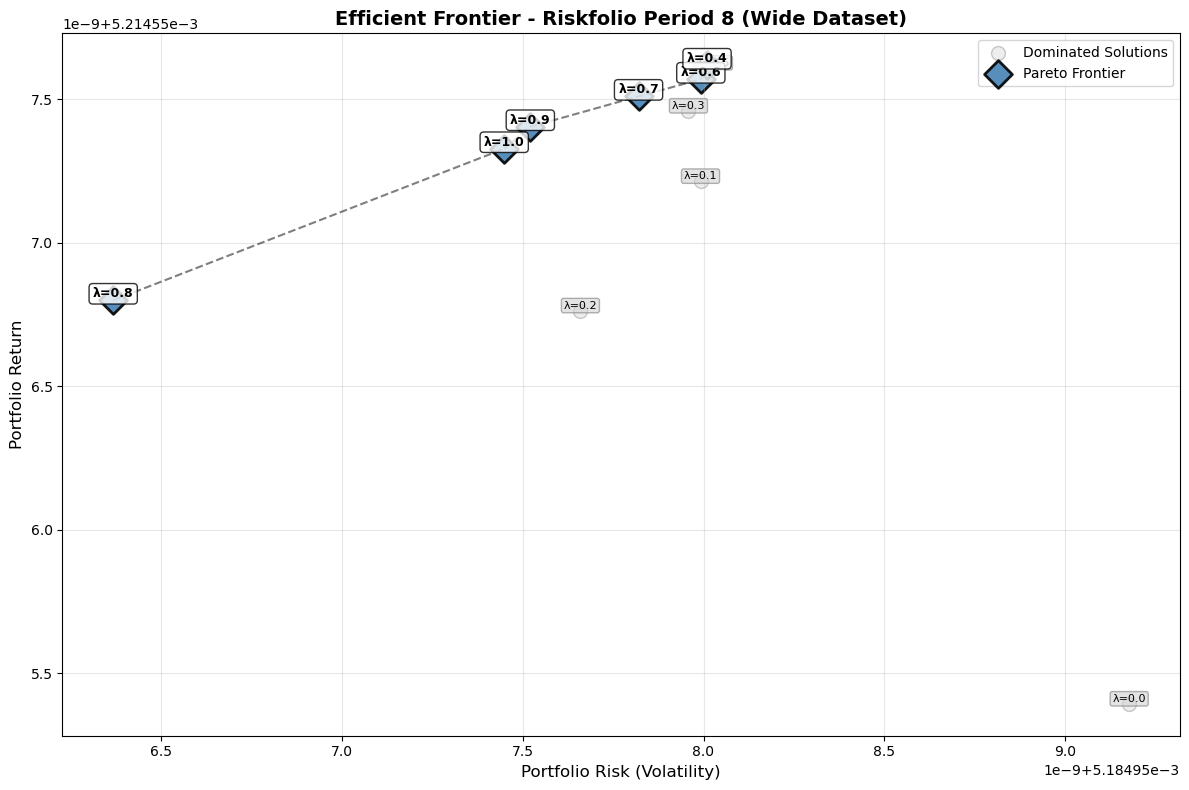


Pareto Frontier Summary:
Total solutions evaluated: 11
Pareto-optimal solutions: 6
Efficiency: 54.5%

Pareto Solutions:
Risk Level   Return       Risk         Sharpe      
------------------------------------------------------------
0.800        0.005215     0.005185     1.0057      
1.000        0.005215     0.005185     1.0057      
0.900        0.005215     0.005185     1.0057      
0.700        0.005215     0.005185     1.0057      
0.600        0.005215     0.005185     1.0057      
0.400        0.005215     0.005185     1.0057      

PERIOD 9 - Riskfolio (Wide Dataset)
Loading existing results for period 9...


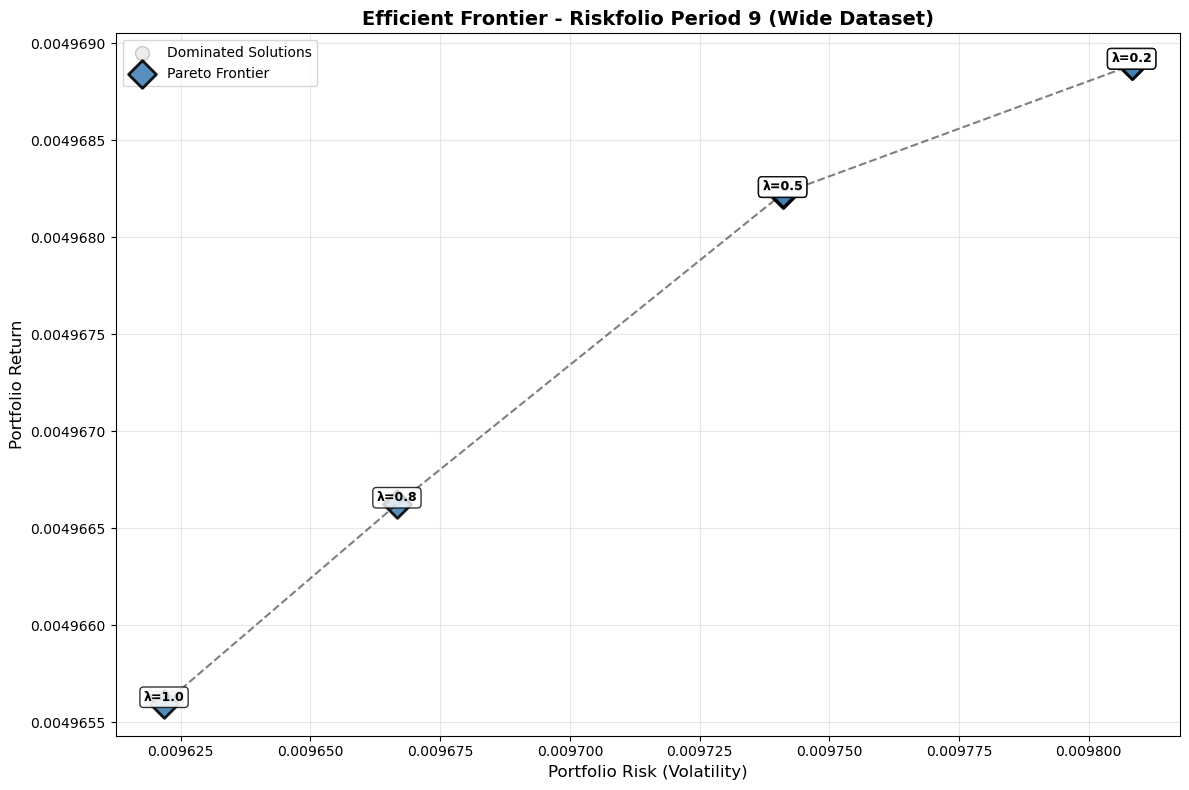


Pareto Frontier Summary:
Total solutions evaluated: 11
Pareto-optimal solutions: 8
Efficiency: 72.7%

Pareto Solutions:
Risk Level   Return       Risk         Sharpe      
------------------------------------------------------------
1.000        0.004966     0.009622     0.5161      
0.800        0.004967     0.009667     0.5138      
0.700        0.004968     0.009741     0.5100      
0.600        0.004968     0.009741     0.5100      
0.500        0.004968     0.009741     0.5100      
0.300        0.004969     0.009808     0.5066      
0.100        0.004969     0.009808     0.5066      
0.200        0.004969     0.009808     0.5066      

Riskfolio - Wide Dataset Complete


In [14]:
for period in range(parameters['n_periods']):
    run_pareto_optimization_period(
        period=period,
        solver_name='Riskfolio',
        solver_key='riskfolio',
        optimization_function=riskfolio_qubo,
        data=source_wide,
        benchmark=benchmark,
        results_dict=all_periods_results_wide['riskfolio'],
        parameters=parameters,
        results_base_path=results_base_path
    )

print(f"\n{'='*80}")
print("Riskfolio - Wide Dataset Complete")
print(f"{'='*80}")

### D-Wave CQM - Wide Dataset (All Periods)

In [ ]:
parameters_dwave = {
    "n_periods": 1,  # Run 10 different time ranges
    "population_size": 100,
    "num_generations": 100,
    "mutation_rate": 0.1,
    "elitism": 0.1,
    "budget": 1_000_000,
    "days_to_avg": 30,  # 30-day averaging period
    "days_to_opt": 30,   # 30-day optimization/testing period
    # Risk levels for Pareto frontier exploration - lambda from 0 to 1 with steps of 0.1
    "risk_levels": [i/10 for i in range(11)]  # [0.0, 0.1, 0.2, ..., 1.0]
}

print(f"Optimization Parameters:")
for key, value in parameters.items():
    print(f"  {key}: {value}")

In [ ]:
# Add D-Wave to results dictionary
all_periods_results_wide['dwave_cqm'] = {}

for period in range(parameters_dwave['n_periods']):
    run_pareto_optimization_period(
        period=period,
        solver_name='D-Wave CQM',
        solver_key='dwave_cqm',
        optimization_function=dwave_cqm_qubo,
        data=source_wide,
        benchmark=benchmark,
        results_dict=all_periods_results_wide['dwave_cqm'],
        parameters=parameters_dwave,
        results_base_path=results_base_path,
        budget=parameters_dwave['budget']
    )

print(f"\n{'='*80}")
print("D-Wave CQM - Wide Dataset Complete")
print(f"{'='*80}")

### Aggregate Results - Wide Dataset

In [ ]:
# Aggregate results across all periods function
def aggregate_results(all_periods_dict):
    """Aggregate results across all periods for a given solver"""
    aggregated = {}
    
    # Get all risk levels from first period
    first_period = list(all_periods_dict.values())[0]
    risk_levels = list(first_period.keys())
    
    for risk_level in risk_levels:
        returns = []
        risks = []
        sharpes = []
        exec_times = []
        
        for period_results in all_periods_dict.values():
            if risk_level in period_results and period_results[risk_level] is not None:
                returns.append(period_results[risk_level]['portfolio_return'])
                risks.append(period_results[risk_level]['portfolio_risk'])
                sharpes.append(period_results[risk_level]['sharpe_ratio'])
                exec_times.append(period_results[risk_level]['execution_time'])
        
        if returns:  # Only create entry if we have data
            aggregated[risk_level] = {
                'portfolio_return': np.mean(returns),
                'portfolio_risk': np.mean(risks),
                'sharpe_ratio': np.mean(sharpes),
                'execution_time': np.mean(exec_times),
                'risk_level': risk_level,
                'return_std': np.std(returns),
                'risk_std': np.std(risks),
                'sharpe_std': np.std(sharpes),
                'n_periods': len(returns)
            }
    
    return aggregated

# Aggregate results for each solver
aggregated_ga_wide = aggregate_results(all_periods_results_wide['genetic_algorithm'])
aggregated_slsqp_wide = aggregate_results(all_periods_results_wide['scipy_slsqp'])
aggregated_riskfolio_wide = aggregate_results(all_periods_results_wide['riskfolio'])
aggregated_dwave_wide = aggregate_results(all_periods_results_wide['dwave_cqm'])

# Plot aggregated Pareto frontiers
frontiers_wide = {
    'Genetic Algorithm': aggregated_ga_wide,
    'SciPy SLSQP': aggregated_slsqp_wide,
    'Riskfolio': aggregated_riskfolio_wide,
    'D-Wave CQM': aggregated_dwave_wide
}

compare_pareto_frontiers(frontiers_wide, title="Pareto Frontier Comparison - Diversified QUBO (Wide Dataset - 680 Assets, Averaged Across 10 Periods)")

# Print summary statistics
print("\n" + "=" * 80)
print("AGGREGATED RESULTS - DIVERSIFIED QUBO (Wide Dataset - 680 Assets)")
print("=" * 80)
for method, results in [('Genetic Algorithm', aggregated_ga_wide), 
                        ('SciPy SLSQP', aggregated_slsqp_wide),
                        ('Riskfolio', aggregated_riskfolio_wide),
                        ('D-Wave CQM', aggregated_dwave_wide)]:
    print(f"\n{method}:")
    if results:
        print(f"  Valid risk levels: {len(results)}/{len(parameters['risk_levels'])}")
        print(f"  Average execution time: {np.mean([r['execution_time'] for r in results.values()]):.2f}s")
    else:
        print("  No valid results")
print("=" * 80)

In [16]:
# Plot weight evolution for aggregated SLSQP results
pareto_slsqp_wide = extract_pareto_frontier(aggregated_slsqp_wide)
if pareto_slsqp_wide:
    print(f"Pareto-optimal solutions (SLSQP - Wide): {len(pareto_slsqp_wide)}")
else:
    print("No Pareto-optimal solutions found for SLSQP (Wide Dataset)")

Pareto-optimal solutions (SLSQP - Wide): 7


## Summary and Insights

In [ ]:
print("=" * 80)
print("PARETO FRONTIER ANALYSIS SUMMARY - DIVERSIFIED QUBO")
print("=" * 80)

print(f"\nAnalysis Configuration:")
print(f"  Optimization Type: Diversified (Restricted) QUBO")
print(f"  Number of periods: {parameters['n_periods']}")
print(f"  Days for averaging: {parameters['days_to_avg']}")
print(f"  Days for optimization/testing: {parameters['days_to_opt']}")
print(f"  Budget constraint: ${parameters['budget']:,.0f}")
print(f"  Risk levels tested: {parameters['risk_levels']}")

print("\nWide Dataset (680 Assets - Stocks + ETFs):")
for method, results in frontiers_wide.items():
    pareto = extract_pareto_frontier(results)
    print(f"  {method}: {len(pareto)} Pareto-optimal solutions (averaged across periods)")


## Comprehensive Solver Comparison Across All Periods

In [ ]:
# Comprehensive comparison of all solvers across all periods
def compute_solver_statistics(all_periods_results):
    """
    Compute comprehensive statistics for each solver across all periods.
    
    Returns:
        DataFrame with statistics for each solver
    """
    stats = []
    
    for solver_name, periods_dict in all_periods_results.items():
        all_returns = []
        all_risks = []
        all_sharpes = []
        all_exec_times = []
        pareto_counts = []
        
        for period_idx, period_results in periods_dict.items():
            # Extract Pareto frontier for this period
            pareto = extract_pareto_frontier(period_results)
            pareto_counts.append(len(pareto))
            
            # Collect metrics from all valid results
            for risk_level, result in period_results.items():
                if result is not None and 'portfolio_return' in result:
                    all_returns.append(result['portfolio_return'])
                    all_risks.append(result['portfolio_risk'])
                    all_sharpes.append(result['sharpe_ratio'])
                    all_exec_times.append(result['execution_time'])
        
        stats.append({
            'Solver': solver_name.replace('_', ' ').title(),
            'Avg Return': np.mean(all_returns) if all_returns else 0,
            'Avg Risk': np.mean(all_risks) if all_risks else 0,
            'Avg Sharpe': np.mean(all_sharpes) if all_sharpes else 0,
            'Avg Exec Time (s)': np.mean(all_exec_times) if all_exec_times else 0,
            'Avg Pareto Points': np.mean(pareto_counts) if pareto_counts else 0,
            'Total Solutions': len(all_returns),
            'Std Return': np.std(all_returns) if all_returns else 0,
            'Std Risk': np.std(all_risks) if all_risks else 0,
            'Std Sharpe': np.std(all_sharpes) if all_sharpes else 0
        })
    
    return pd.DataFrame(stats)

# Compute statistics
solver_stats = compute_solver_statistics(all_periods_results_wide)

print("\n" + "="*80)
print("SOLVER PERFORMANCE COMPARISON - ALL PERIODS")
print("="*80)
print(solver_stats.to_string(index=False))
print("="*80)

# Create comprehensive bar plot comparison
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Comprehensive Solver Comparison Across All Periods', fontsize=16, fontweight='bold', y=0.995)

solvers = solver_stats['Solver'].values
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']  # Blue, Orange, Green, Red

# 1. Average Return
ax1 = axes[0, 0]
bars1 = ax1.bar(solvers, solver_stats['Avg Return'], color=colors, alpha=0.8, edgecolor='black')
ax1.set_ylabel('Average Return', fontsize=11, fontweight='bold')
ax1.set_title('Average Portfolio Return', fontsize=12, fontweight='bold')
ax1.tick_params(axis='x', rotation=15)
ax1.grid(True, alpha=0.3, axis='y')
for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.6f}', ha='center', va='bottom', fontsize=9)

# 2. Average Risk
ax2 = axes[0, 1]
bars2 = ax2.bar(solvers, solver_stats['Avg Risk'], color=colors, alpha=0.8, edgecolor='black')
ax2.set_ylabel('Average Risk (Volatility)', fontsize=11, fontweight='bold')
ax2.set_title('Average Portfolio Risk', fontsize=12, fontweight='bold')
ax2.tick_params(axis='x', rotation=15)
ax2.grid(True, alpha=0.3, axis='y')
for bar in bars2:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.6f}', ha='center', va='bottom', fontsize=9)

# 3. Average Sharpe Ratio
ax3 = axes[0, 2]
bars3 = ax3.bar(solvers, solver_stats['Avg Sharpe'], color=colors, alpha=0.8, edgecolor='black')
ax3.set_ylabel('Average Sharpe Ratio', fontsize=11, fontweight='bold')
ax3.set_title('Average Sharpe Ratio', fontsize=12, fontweight='bold')
ax3.tick_params(axis='x', rotation=15)
ax3.grid(True, alpha=0.3, axis='y')
for bar in bars3:
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.4f}', ha='center', va='bottom', fontsize=9)

# 4. Average Execution Time
ax4 = axes[1, 0]
bars4 = ax4.bar(solvers, solver_stats['Avg Exec Time (s)'], color=colors, alpha=0.8, edgecolor='black')
ax4.set_ylabel('Time (seconds)', fontsize=11, fontweight='bold')
ax4.set_title('Average Execution Time per Lambda', fontsize=12, fontweight='bold')
ax4.tick_params(axis='x', rotation=15)
ax4.grid(True, alpha=0.3, axis='y')
for bar in bars4:
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.2f}s', ha='center', va='bottom', fontsize=9)

# 5. Average Pareto Points per Period
ax5 = axes[1, 1]
bars5 = ax5.bar(solvers, solver_stats['Avg Pareto Points'], color=colors, alpha=0.8, edgecolor='black')
ax5.set_ylabel('Average Count', fontsize=11, fontweight='bold')
ax5.set_title('Avg Pareto-Optimal Solutions per Period', fontsize=12, fontweight='bold')
ax5.tick_params(axis='x', rotation=15)
ax5.grid(True, alpha=0.3, axis='y')
ax5.set_ylim([0, max(solver_stats['Avg Pareto Points']) * 1.2])
for bar in bars5:
    height = bar.get_height()
    ax5.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.1f}', ha='center', va='bottom', fontsize=9)

# 6. Total Solutions Found
ax6 = axes[1, 2]
bars6 = ax6.bar(solvers, solver_stats['Total Solutions'], color=colors, alpha=0.8, edgecolor='black')
ax6.set_ylabel('Total Count', fontsize=11, fontweight='bold')
ax6.set_title('Total Valid Solutions Across All Periods', fontsize=12, fontweight='bold')
ax6.tick_params(axis='x', rotation=15)
ax6.grid(True, alpha=0.3, axis='y')
for bar in bars6:
    height = bar.get_height()
    ax6.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# Additional analysis: Consistency across periods
print("\n" + "="*80)
print("SOLVER CONSISTENCY ANALYSIS")
print("="*80)
print(f"{'Solver':<20} {'Std Return':<15} {'Std Risk':<15} {'Std Sharpe':<15}")
print("-"*80)
for _, row in solver_stats.iterrows():
    print(f"{row['Solver']:<20} {row['Std Return']:<15.6f} {row['Std Risk']:<15.6f} {row['Std Sharpe']:<15.6f}")
print("="*80)
print("Lower standard deviation indicates more consistent performance across periods.")
